# D_S2.1 — Filtered Analysis: MIC ≥ 0.8 & dcor ≥ 0.7

Filter cases from S2 where **both** MIC ≥ 0.8 and distance correlation ≥ 0.8,
then visualise the qualifying families across all four key metrics.

In [484]:
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                      'figure.facecolor': 'white'})

In [485]:
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
meta = cases[['case_id', 'family_id', 'snr', 'category', 'replicate']].copy()
df = metrics.merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))
signal = df[df['family_id'] != 'Null'].copy()
print(f'Total signal cases: {len(signal):,}')
print(f'Families: {sorted(signal["family_id"].unique())}')

Total signal cases: 156,780
Families: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']


In [486]:
FAMILY_PALETTE = {
    'F01': '#4FC3F7',  'F02': '#29B6F6',  'F03': '#81C784',  'F04': '#26C6DA',
    'F05': '#AED581',  'F06': '#43A047',  'F07': '#F48FB1',  'F08': '#CE93D8',
    'F09': '#80DEEA',  'F10': '#80CBC4',  'F11': '#FFE082',  'F12': '#F9A825',
    'F13': '#8D6E63',  'F14': '#A1887F',  'F15': '#78909C',  'F16': '#90A4AE',
    'F17': '#C62828',  'F18': '#AD1457',  'F19': '#6A1B9A',  'F20': '#4527A0',
    'F21': '#1565C0',  'F22': '#00838F',  'F23': '#2E7D32',  'F24': '#FF7043',
    'F25': '#D84315',  'F26': '#4E342E',  'Null': '#BDBDBD',
}

SHORT = {
    'F01': 'Linear(+)',     'F02': 'Linear(−)',     'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(−)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(−)',
    'F07': 'Sat(+)',        'F08': 'Sat(−)',        'F09': 'Log(+)',
    'F10': 'Log(−)',        'F11': 'Exp(+)',        'F12': 'Exp(−)',
    'F13': 'S-crv(+)',      'F14': 'S-crv(−)',      'F15': 'Thresh(+)',
    'F16': 'Thresh(−)',     'F17': 'Peak(∩)',       'F18': 'Valley(∪)',
    'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
    'F22': 'Oscillation',       'F23': 'Two Lines',     'F24': 'L+Parab',
    'F25': 'Multi-reg',     'F26': 'Windowed J',
}

COMB_METRICS = [
    ('MIC', 'MIC'),
    ('distance_correlation', 'dcor'),
    ('MEV', 'MEV'),
    ('equal_count_bin_eta_squared', 'η²(EQ)'),
]

all_fids = [f'F{i:02d}' for i in range(1, 27)]

## Step 1 — Filter: MIC ≥ 0.8 AND dcor ≥ 0.8

In [487]:
MIC_THRESH = 0.8
DCOR_THRESH = 0.8

# Per-case filter: each individual case must have MIC ≥ threshold AND dcor ≥ threshold
filtered_cases = signal[
    (signal['MIC'] >= MIC_THRESH) & (signal['distance_correlation'] >= DCOR_THRESH)
].copy()
qual_fids = sorted(filtered_cases['family_id'].unique())

print(f'═══ Step 1: Global Relationship Filter ═══')
print(f'Rule: MIC ≥ {MIC_THRESH} AND dcor ≥ {DCOR_THRESH}  (per case)')
print(f'')
print(f'  Total families:       {len(all_fids)}')
print(f'  Total cases:          {len(signal):,}')
print(f'')
print(f'  ➜ Qualifying cases:   {len(filtered_cases):,} / {len(signal):,}  ({len(filtered_cases)/len(signal):.1%})')
print(f'  ➜ Qualifying families: {len(qual_fids)} / {len(all_fids)}  — {qual_fids}')
print(f'  ➜ Excluded families:   {sorted(set(all_fids) - set(qual_fids))}')

# For each family, show filtered cases / total cases (two-column layout)
total_cases_per_fid = signal.groupby('family_id').size()

rows = []
for fid in all_fids:
    n_total = total_cases_per_fid.get(fid, 0)
    n_pass = len(filtered_cases[filtered_cases['family_id'] == fid]) if fid in filtered_cases['family_id'].values else 0
    pct = n_pass / n_total if n_total > 0 else 0
    mark = '✓' if fid in qual_fids else ' '
    rows.append(f'{fid} {SHORT[fid]:<12} {n_pass:>5}/{n_total:<5} {pct:>4.0%} {mark}')

mid = (len(rows) + 1) // 2
col_w = 38
print()
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


═══ Step 1: Global Relationship Filter ═══
Rule: MIC ≥ 0.8 AND dcor ≥ 0.8  (per case)

  Total families:       26
  Total cases:          156,780

  ➜ Qualifying cases:   32,570 / 156,780  (20.8%)
  ➜ Qualifying families: 19 / 26  — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21', 'F22', 'F23']
  ➜ Excluded families:   ['F17', 'F18', 'F19', 'F20', 'F24', 'F25', 'F26']

F01 Linear(+)     2151/6030   36% ✓     F14 S-crv(−)      2396/6030   40% ✓
F02 Linear(−)     2162/6030   36% ✓     F15 Thresh(+)     2440/6030   40% ✓
F03 PwrCvx(+)     1890/6030   31% ✓     F16 Thresh(−)     2449/6030   41% ✓
F04 PwrCvx(−)     1899/6030   31% ✓     F17 Peak(∩)          0/6030    0%  
F05 PwrCcv(+)     1974/6030   33% ✓     F18 Valley(∪)        0/6030    0%  
F06 PwrCcv(−)     1981/6030   33% ✓     F19 Spike            0/6030    0%  
F07 Sat(+)        1126/6030   19% ✓     F20 Inv Spike        0/6030    0%  
F08 Sat(−)        1120/60

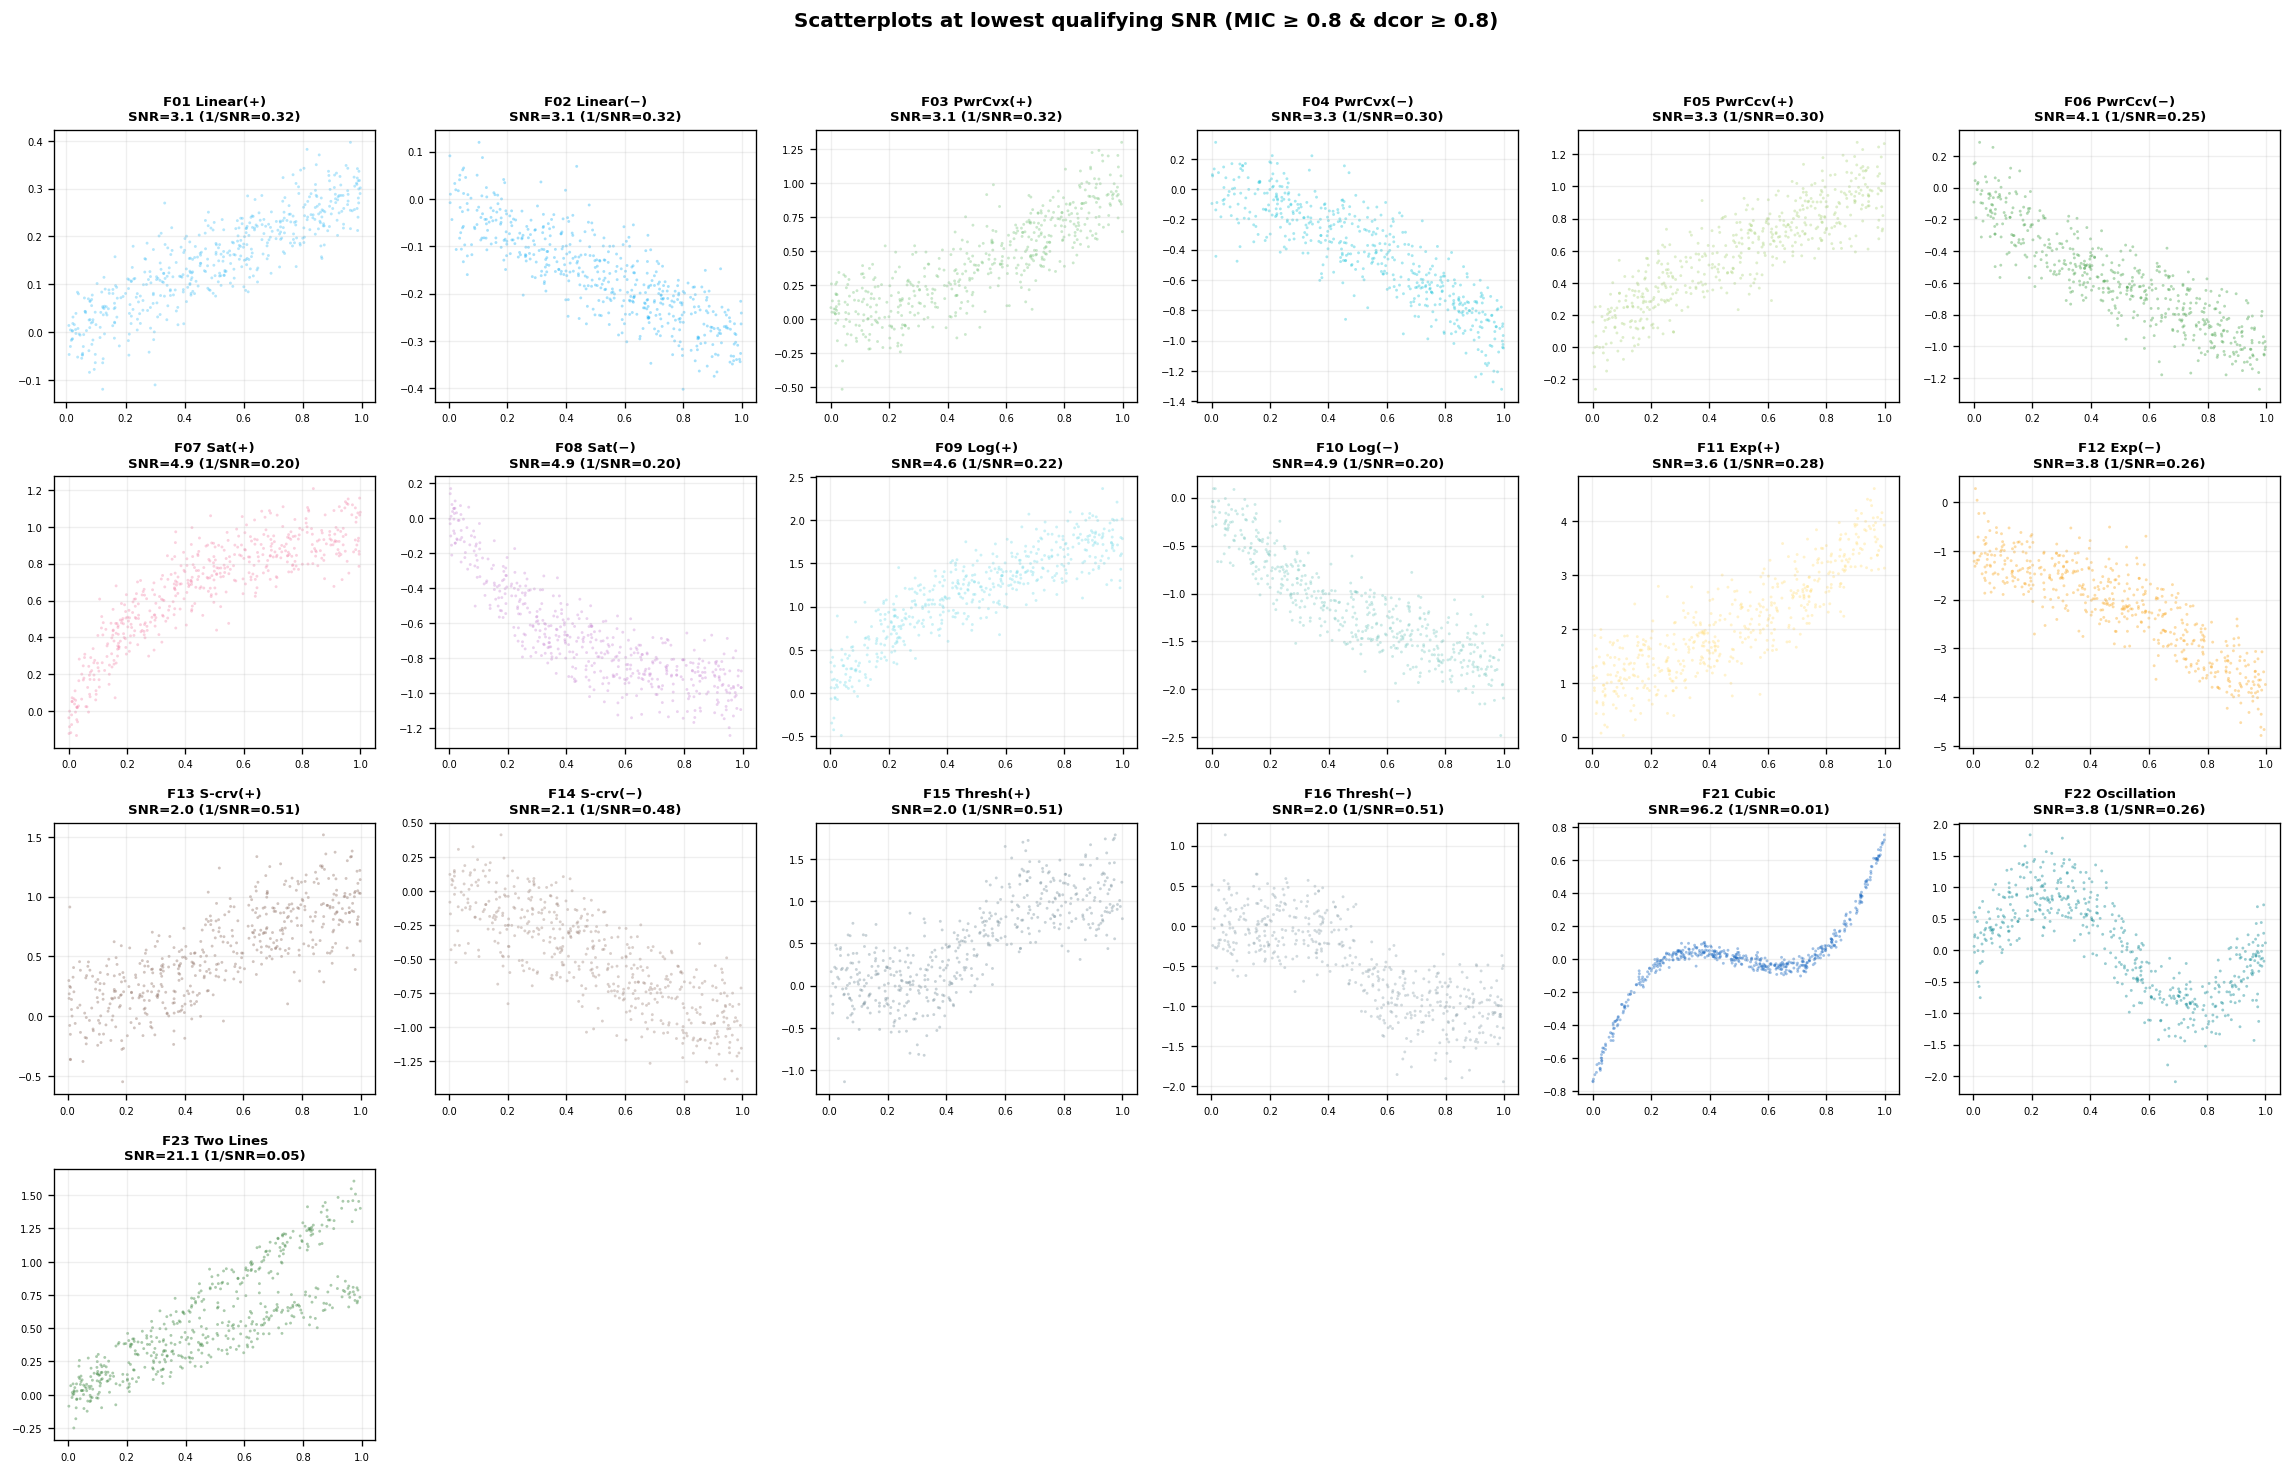

In [488]:
# ── Scatterplots: each family at its lowest qualifying SNR ──

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

ncols = 6
nrows = math.ceil(len(qual_fids) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3 * nrows))
axes = axes.flatten()

for i, fid in enumerate(qual_fids):
    ax = axes[i]
    # Find lowest finite SNR that passes filter
    fsub = filtered_cases[filtered_cases['family_id'] == fid]
    finite_snrs = fsub['snr_val'][np.isfinite(fsub['snr_val'])].drop_duplicates().sort_values()
    if len(finite_snrs) == 0:
        ax.set_visible(False)
        continue
    low_snr = finite_snrs.iloc[0]
    # Pick first replicate at this (family, snr)
    match = cases_df[(cases_df['family_id'] == fid) & (cases_df['snr'] == low_snr)]
    if len(match) == 0:
        ax.set_visible(False)
        continue
    idx = match.index[0]
    x, y = X_all[idx], Y_all[idx]
    ax.scatter(x, y, s=3, alpha=0.4, color=FAMILY_PALETTE[fid], edgecolors='none')
    ax.set_title(f'{fid} {SHORT[fid]}\nSNR={low_snr:.1f} (1/SNR={1/low_snr:.2f})',
                 fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.2)

for j in range(len(qual_fids), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Scatterplots at lowest qualifying SNR (MIC ≥ {MIC_THRESH} & dcor ≥ {DCOR_THRESH})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


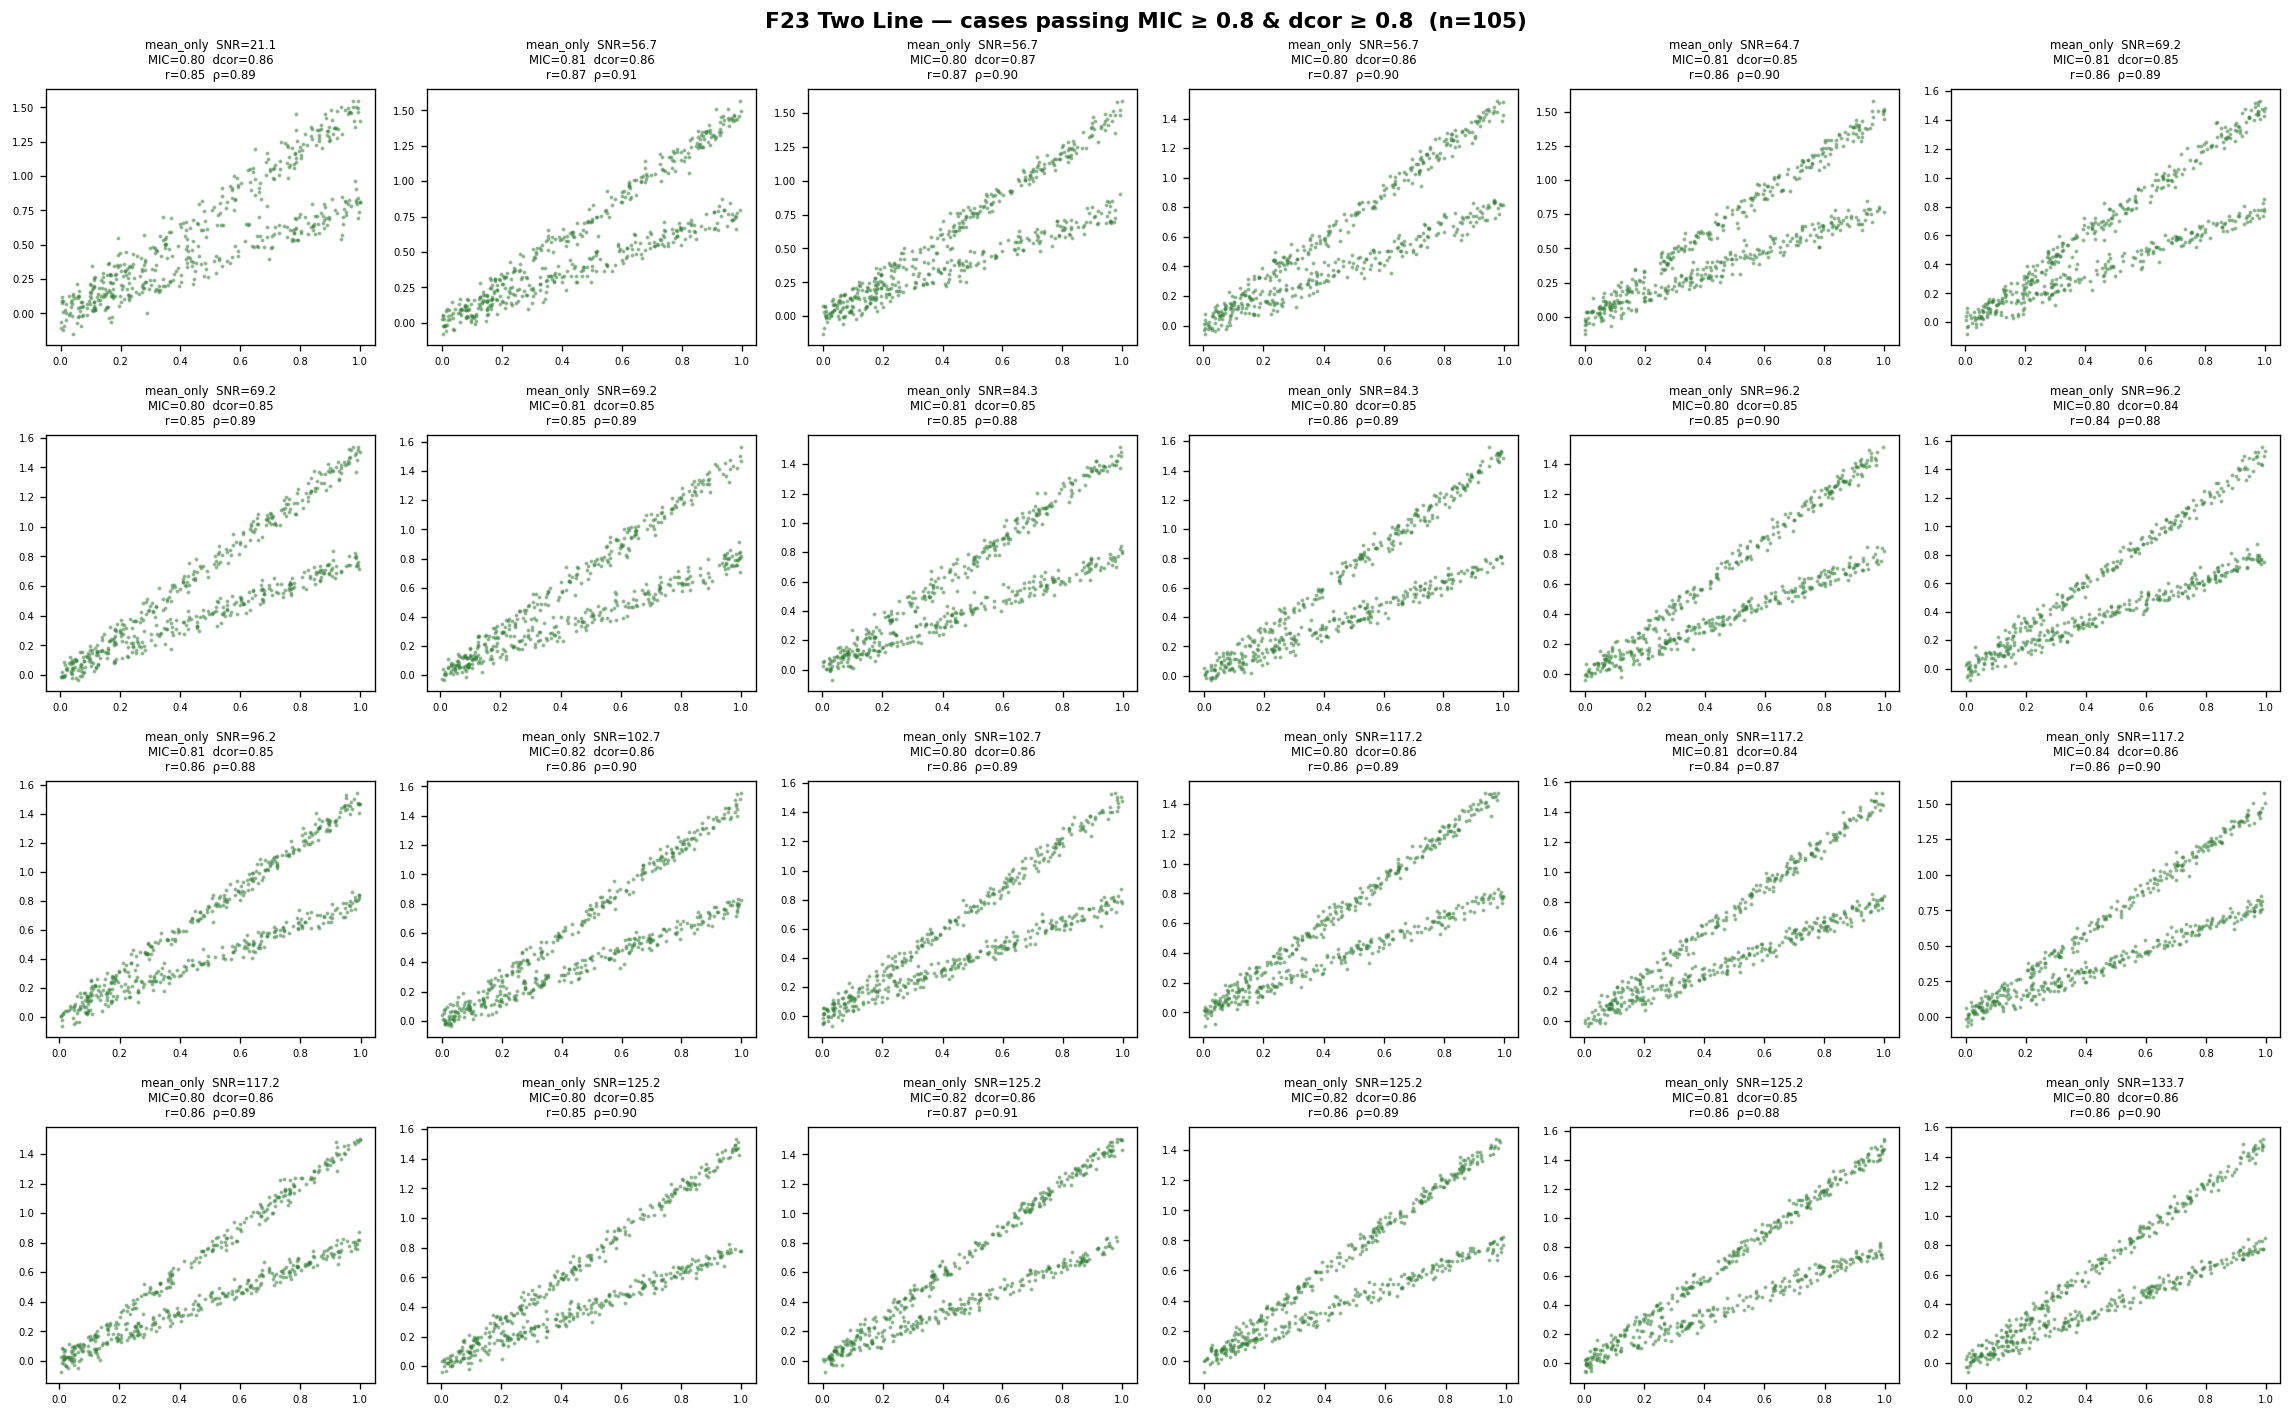

F23 qualifying cases: 105
SNR range: 21.10 – inf
Categories: {'mean_only': 105}


In [489]:
# ── F23 Two Line: scatterplots of cases passing MIC ≥ 0.8 & dcor ≥ 0.8 ──

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

f23_pass = filtered_cases[filtered_cases['family_id'] == 'F23'].copy()
f23_pass = f23_pass.sort_values('snr_val', ascending=True)

n_show = min(len(f23_pass), 24)
ncols = 6
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for i in range(n_show):
    ax = axes[i]
    row = f23_pass.iloc[i]
    cid = row['case_id']
    match = cases_df[cases_df['case_id'] == cid]
    if len(match) == 0:
        ax.set_visible(False)
        continue
    idx = match.index[0]
    x, y = X_all[idx], Y_all[idx]
    ax.scatter(x, y, s=2, alpha=0.4, color=FAMILY_PALETTE.get('F23', '#888'))
    snr_str = f'SNR={row["snr_val"]:.1f}' if np.isfinite(row['snr_val']) else 'SNR=∞'
    ax.set_title(f'{row["category"]}  {snr_str}\n'
                 f'MIC={row["MIC"]:.2f}  dcor={row["distance_correlation"]:.2f}\n'
                 f'r={row["pearson_r"]:.2f}  ρ={row["spearman_rho"]:.2f}',
                 fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'F23 Two Line — cases passing MIC ≥ {MIC_THRESH} & dcor ≥ {DCOR_THRESH}  (n={len(f23_pass)})',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print(f'F23 qualifying cases: {len(f23_pass)}')
print(f'SNR range: {f23_pass["snr_val"].min():.2f} – {f23_pass["snr_val"].max()}')
print(f'Categories: {f23_pass["category"].value_counts().to_dict()}')

In [490]:
# ── Separate filter comparison: MIC only vs dcor only (per case) ──

mic_cases = signal[signal['MIC'] >= MIC_THRESH]
dcor_cases = signal[signal['distance_correlation'] >= DCOR_THRESH]

mic_fids = sorted(mic_cases['family_id'].unique())
dcor_fids = sorted(dcor_cases['family_id'].unique())
both_fids = sorted(set(mic_fids) & set(dcor_fids))
mic_not_dcor = sorted(set(mic_fids) - set(dcor_fids))
dcor_not_mic = sorted(set(dcor_fids) - set(mic_fids))

print(f'MIC ≥ {MIC_THRESH} only:  {len(mic_fids)} families — {mic_fids}')
print(f'dcor ≥ {DCOR_THRESH} only: {len(dcor_fids)} families — {dcor_fids}')
print(f'Both:              {len(both_fids)} families — {both_fids}')
print(f'MIC only (not dcor): {mic_not_dcor}')
print(f'dcor only (not MIC): {dcor_not_mic}')

# Detail table for families that differ
diff_fids = sorted(set(mic_not_dcor) | set(dcor_not_mic))
if diff_fids:
    total_per_fid = signal.groupby('family_id').size()
    print(f'\n{"Family":<28} {"MIC pass":>9} {"dcor pass":>10} {"max MIC":>8} {"max dcor":>9}')
    print('─' * 68)
    for fid in diff_fids:
        sub = signal[signal['family_id'] == fid]
        n_mic = (sub['MIC'] >= MIC_THRESH).sum()
        n_dcor = (sub['distance_correlation'] >= DCOR_THRESH).sum()
        print(f'{fid + " " + SHORT.get(fid, ""):<28} '
              f'{n_mic:>8} {n_dcor:>10} '
              f'{sub["MIC"].max():>8.3f} {sub["distance_correlation"].max():>9.3f}')


MIC ≥ 0.8 only:  25 families — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F25', 'F26']
dcor ≥ 0.8 only: 19 families — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21', 'F22', 'F23']
Both:              19 families — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21', 'F22', 'F23']
MIC only (not dcor): ['F17', 'F18', 'F19', 'F20', 'F25', 'F26']
dcor only (not MIC): []

Family                        MIC pass  dcor pass  max MIC  max dcor
────────────────────────────────────────────────────────────────────
F17 Peak(∩)                      2017          0    1.000     0.525
F18 Valley(∪)                    2019          0    1.000     0.526
F19 Spike                         869          0    1.000     0.529
F20 Inv Spike                 

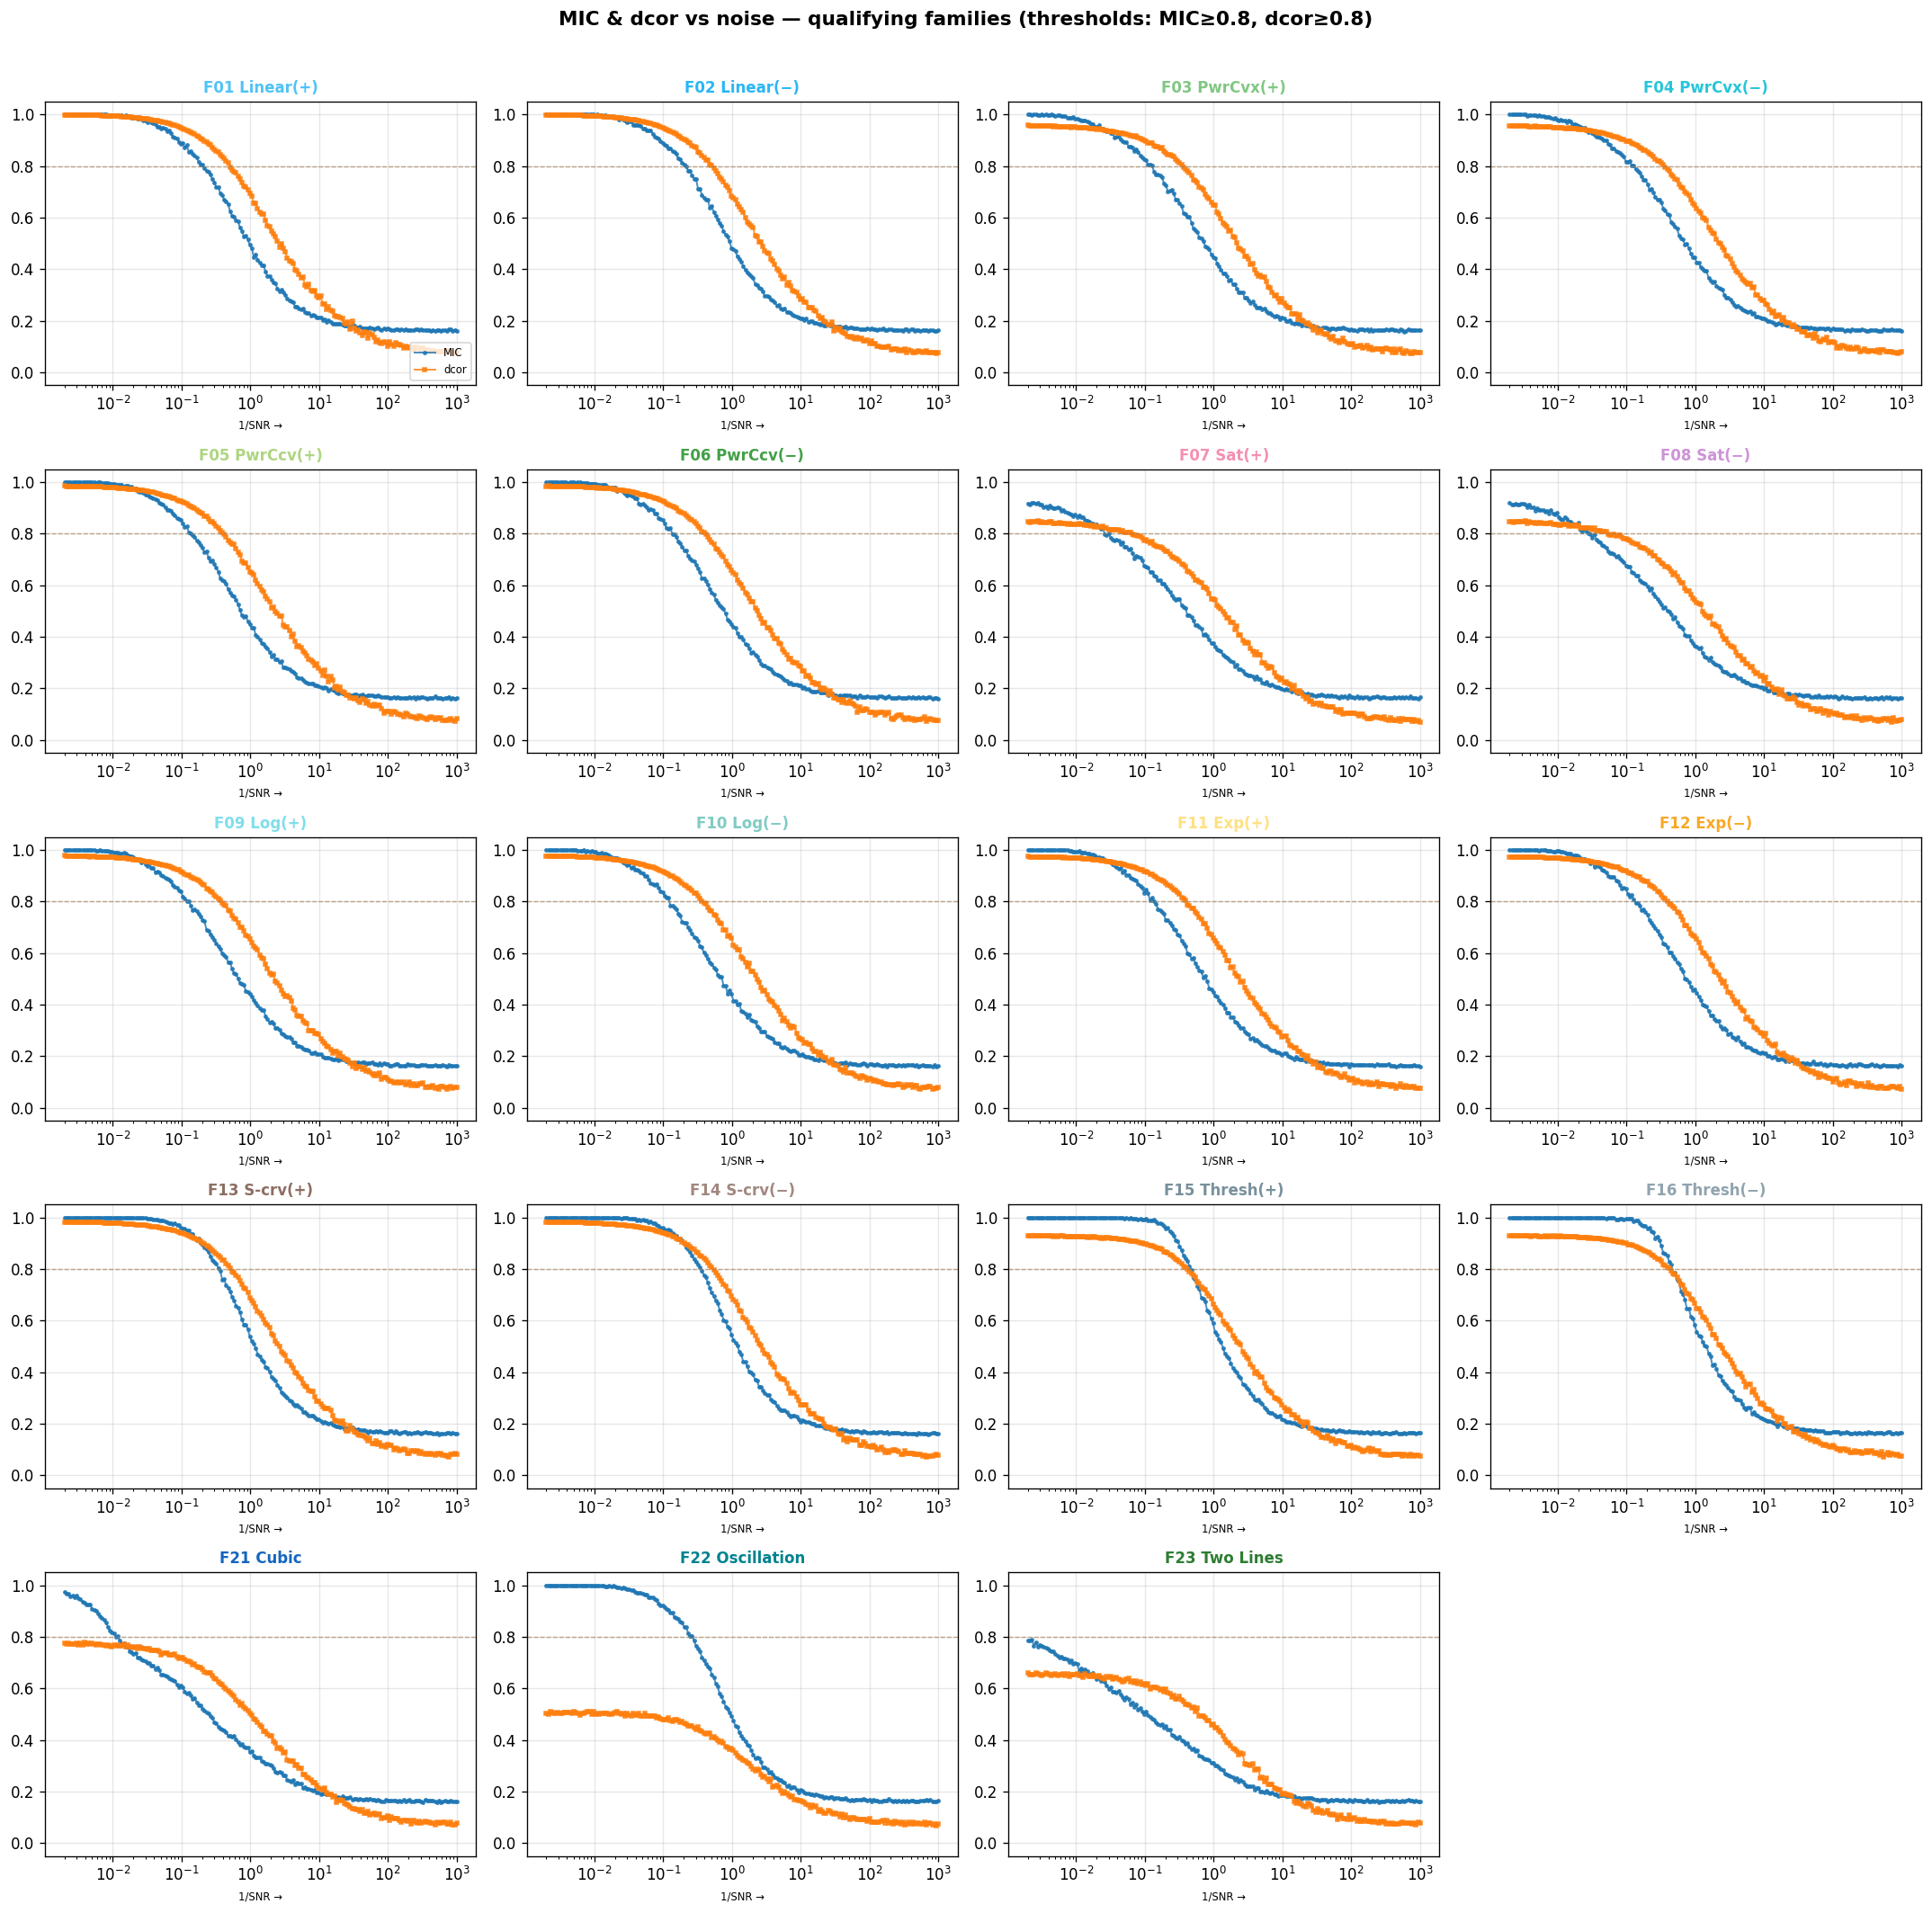

In [491]:
# ── MIC & dcor two-line plots per qualifying family ──
n_fams = len(qual_fids)
n_cols = 4
n_rows = math.ceil(n_fams / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows), squeeze=False)

for idx, fid in enumerate(qual_fids):
    ax = axes[idx // n_cols][idx % n_cols]
    sub = signal[signal['family_id'] == fid].copy()
    sub = sub[np.isfinite(sub['snr_val']) & (sub['snr_val'] > 0)].copy()
    sub['noise_ratio'] = 1.0 / sub['snr_val']

    agg = sub.groupby('noise_ratio').agg(
        MIC=('MIC', 'mean'),
        dcor=('distance_correlation', 'mean'),
    ).reset_index().sort_values('noise_ratio')

    ax.plot(agg['noise_ratio'], agg['MIC'], '-o', color='tab:blue',
            markersize=2, linewidth=1.2, alpha=0.8, label='MIC')
    ax.plot(agg['noise_ratio'], agg['dcor'], '-s', color='tab:orange',
            markersize=2, linewidth=1.2, alpha=0.8, label='dcor')
    ax.axhline(MIC_THRESH, color='tab:blue', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(DCOR_THRESH, color='tab:orange', ls='--', lw=0.8, alpha=0.4)
    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{fid} {SHORT[fid]}', fontsize=10, fontweight='bold',
                 color=FAMILY_PALETTE[fid])
    ax.set_xlabel('1/SNR →', fontsize=7)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, loc='lower right')

for idx in range(n_fams, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle(f'MIC & dcor vs noise — qualifying families (thresholds: MIC≥{MIC_THRESH}, dcor≥{DCOR_THRESH})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 2 — Metric vs 1/SNR (only qualifying families & SNR levels)

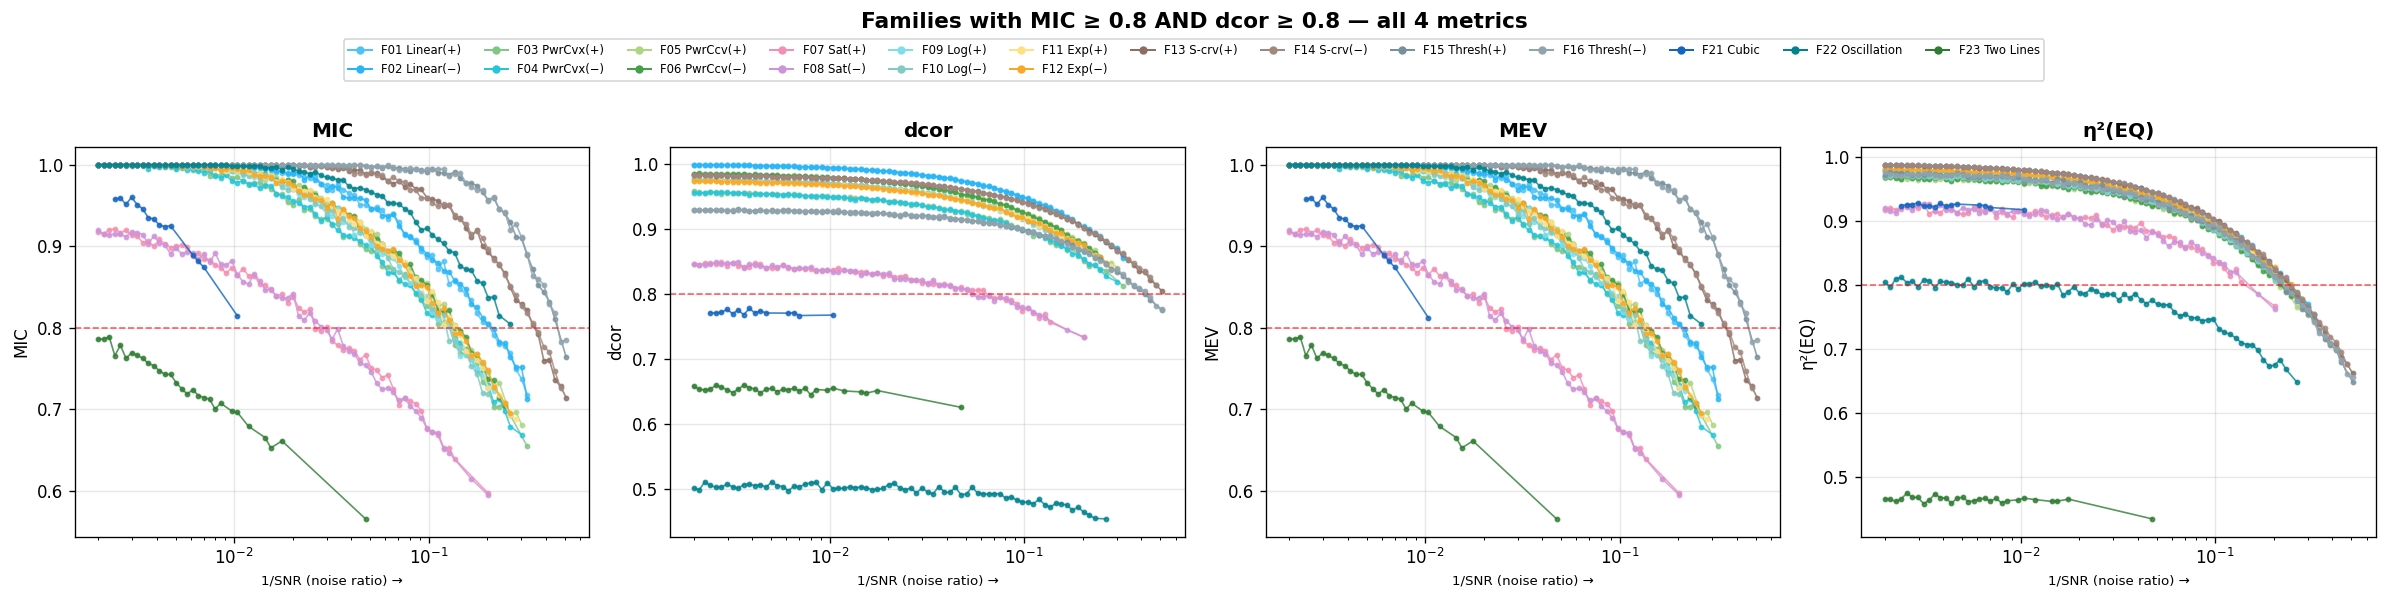

In [492]:
# ── 1×4 combined: only families/SNR pairs where MIC ≥ 0.8 & dcor ≥ 0.8 ──

fig, axes = plt.subplots(1, len(COMB_METRICS), figsize=(5 * len(COMB_METRICS), 4.5))

for ax, (col, label) in zip(axes, COMB_METRICS):
    for fid in qual_fids:
        # Only plot (family, snr) pairs that passed the dual filter
        pass_snrs = set(filtered_cases[filtered_cases['family_id'] == fid]['snr_val'])
        sub = signal[signal['family_id'] == fid]
        agg_full = sub.groupby('snr_val')[col].mean().reset_index()
        agg_full = agg_full[agg_full['snr_val'].isin(pass_snrs)].copy()
        agg_full = agg_full[np.isfinite(agg_full['snr_val']) & (agg_full['snr_val'] > 0)].copy()
        if len(agg_full) == 0:
            continue
        agg_full['noise_ratio'] = 1.0 / agg_full['snr_val']
        agg_full = agg_full.sort_values('noise_ratio')
        ax.plot(agg_full['noise_ratio'], agg_full[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.axhline(MIC_THRESH, color='red', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel(label)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=FAMILY_PALETTE[f], marker='o',
                  markersize=4, linewidth=1.2,
                  label=f'{f} {SHORT.get(f, "")}') for f in qual_fids]
fig.legend(handles=handles, loc='upper center', ncol=min(13, len(qual_fids)),
           fontsize=7, frameon=True, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f'Families with MIC ≥ {MIC_THRESH} AND dcor ≥ {DCOR_THRESH} — all 4 metrics',
             fontsize=13, fontweight='bold', y=1.10)
plt.tight_layout()
plt.show()

## Step 3 — Scatterplots at the MIC & dcor ≈ 0.8 boundary


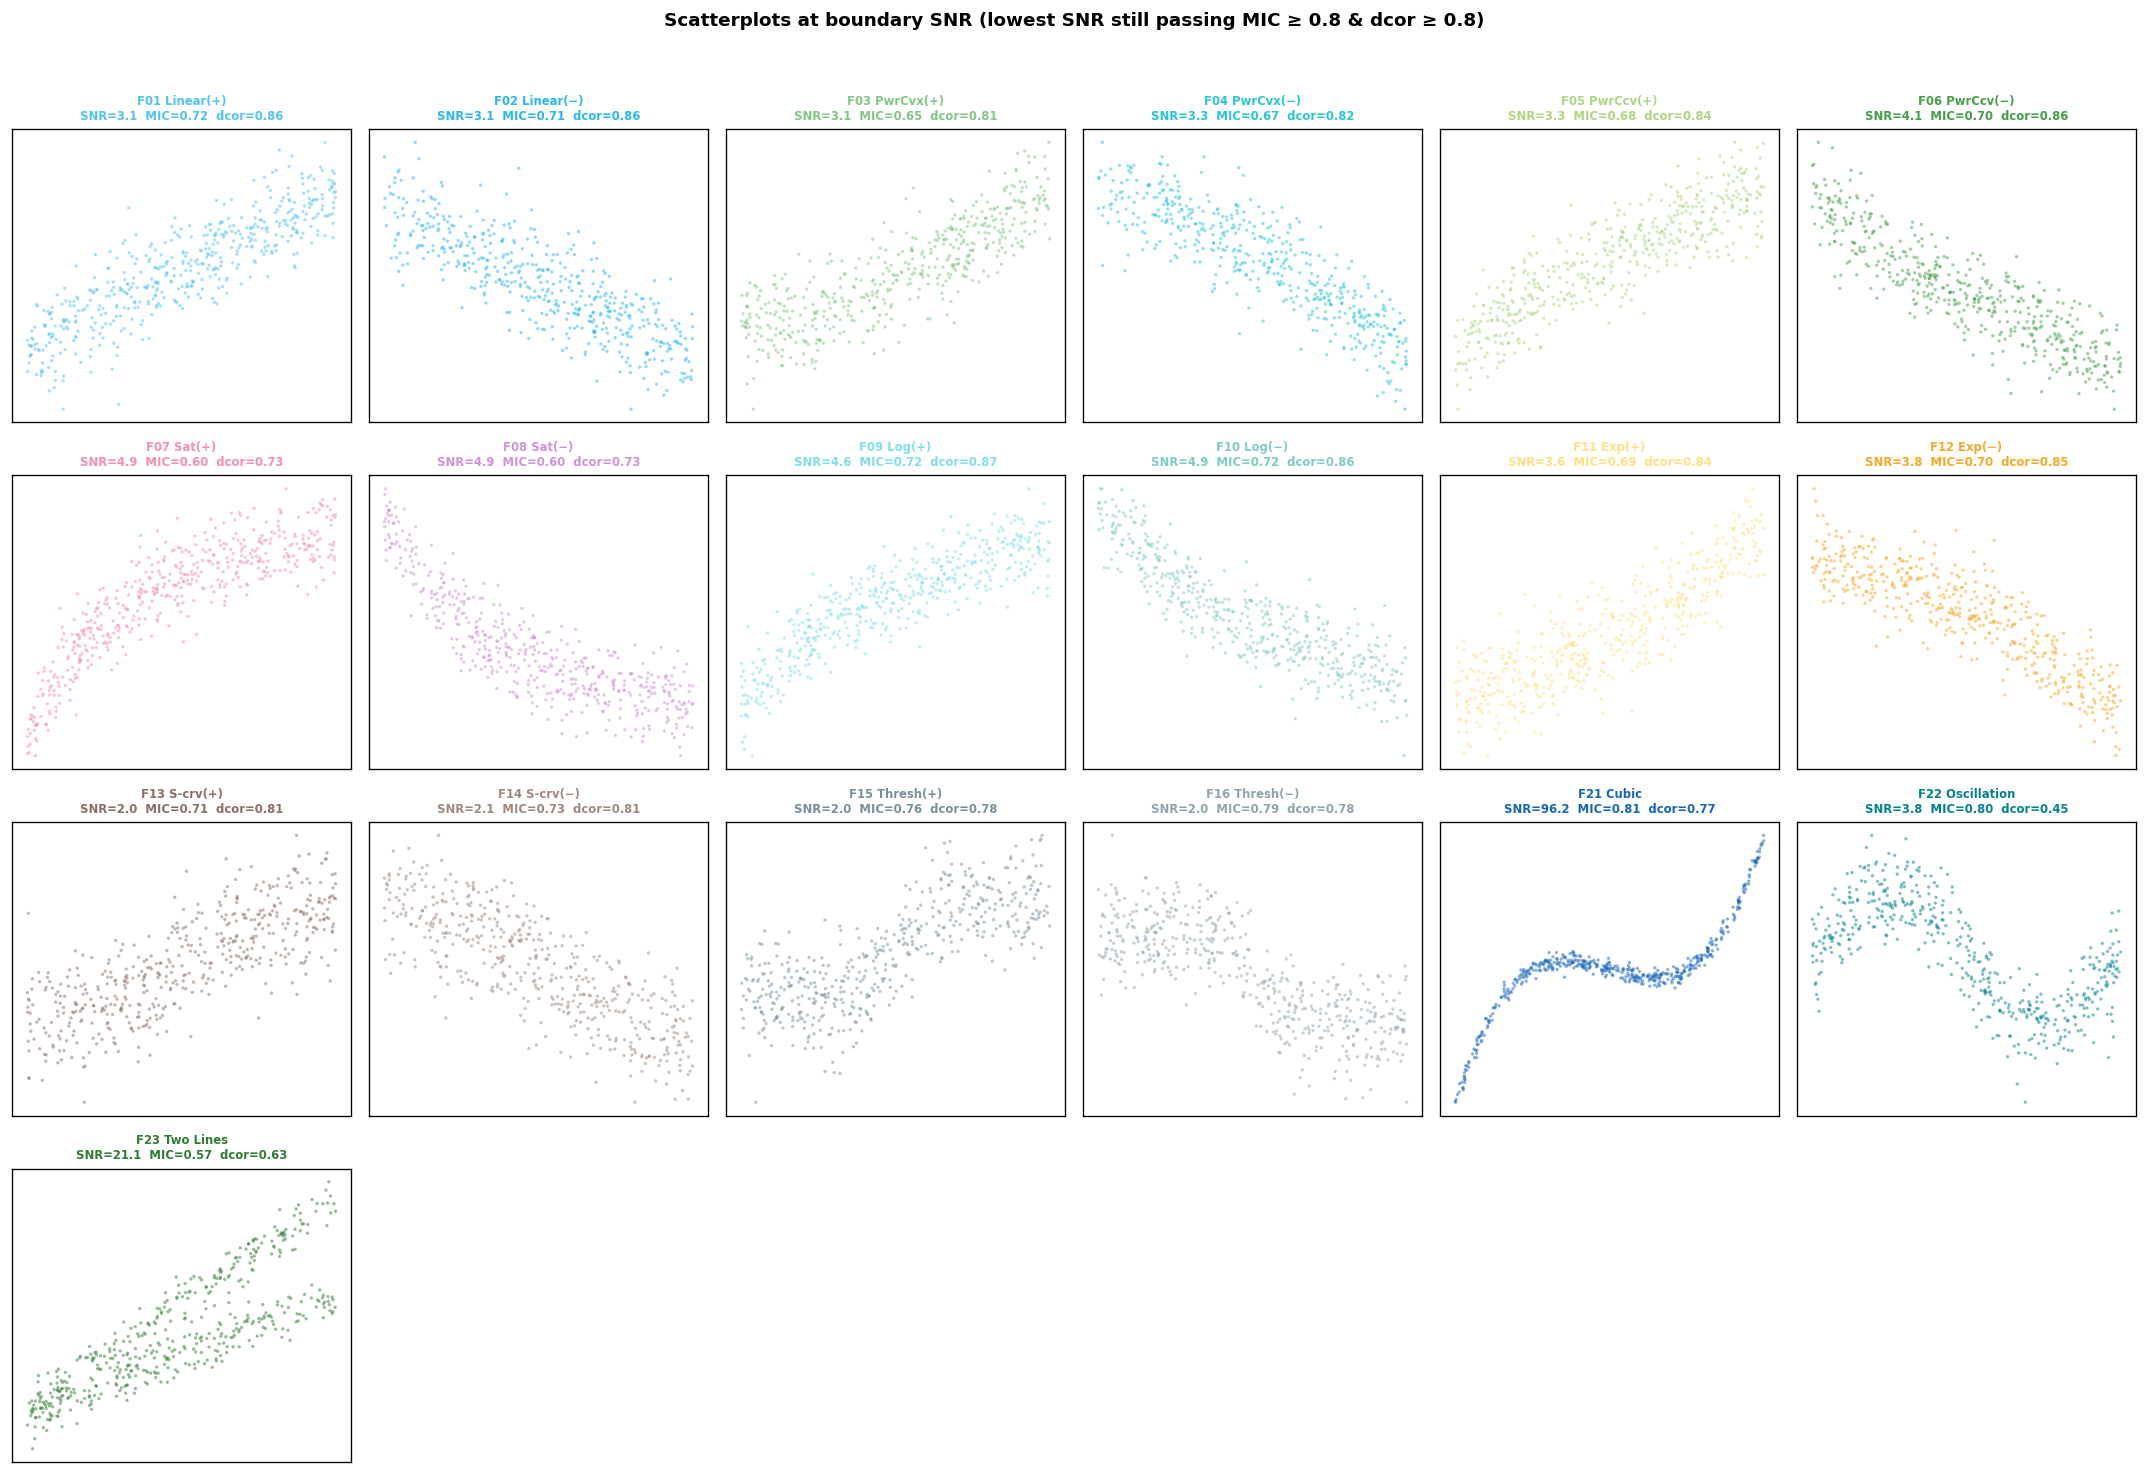

In [493]:
# ── Scatterplots: each qualifying family at the SNR where it drops below the dual threshold ──

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_df['snr_f'] = cases_df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

n = len(qual_fids)
ncols_g = min(6, n)
nrows_g = math.ceil(n / ncols_g)
fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(3 * ncols_g, 3 * nrows_g))
if nrows_g * ncols_g == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes).reshape(nrows_g, ncols_g)

for idx, fid in enumerate(qual_fids):
    r, c = divmod(idx, ncols_g)
    ax = axes[r, c]

    # Find the lowest SNR that still passes the dual filter
    pass_snrs = filtered_cases[filtered_cases['family_id'] == fid]['snr_val'].drop_duplicates()
    finite_pass = pass_snrs[np.isfinite(pass_snrs)]
    if len(finite_pass) == 0:
        ax.set_visible(False)
        continue
    boundary_snr = finite_pass.min()

    pick = cases_df[(cases_df['family_id'] == fid) &
                    (np.isclose(cases_df['snr_f'], boundary_snr, rtol=1e-6)) &
                    (cases_df['replicate'] == 0)]
    if len(pick) == 0:
        pick = cases_df[(cases_df['family_id'] == fid) &
                        (np.isclose(cases_df['snr_f'], boundary_snr, rtol=1e-3))].head(1)
    if len(pick) == 0:
        ax.set_visible(False)
        continue
    ci = pick.index[0]

    # Get actual metric values at this SNR
    sub = signal[(signal['family_id'] == fid) & (np.isclose(signal['snr_val'], boundary_snr, rtol=1e-6))]
    mic_val = sub['MIC'].mean()
    dcor_val = sub['distance_correlation'].mean()

    ax.scatter(X_all[ci], Y_all[ci], s=4, alpha=0.5,
               color=FAMILY_PALETTE[fid], edgecolors='none')
    ax.set_title(f'{fid} {SHORT[fid]}\nSNR={boundary_snr:.1f}  MIC={mic_val:.2f}  dcor={dcor_val:.2f}',
                 fontsize=7, fontweight='bold', color=FAMILY_PALETTE[fid])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, alpha=0.2)

for idx in range(n, nrows_g * ncols_g):
    r, c = divmod(idx, ncols_g)
    axes[r, c].set_visible(False)

fig.suptitle(f'Scatterplots at boundary SNR (lowest SNR still passing MIC ≥ {MIC_THRESH} & dcor ≥ {DCOR_THRESH})',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — Complexity Classification: Pearson/Spearman + MAS/MIC-r²

═══ Step 4: Simple/Complex Classification ═══
Input: 32,570 cases from Step 1  (out of 156,780 total)
Rule:  |r| ≥ 0.7  AND  |ρ| ≥ 0.7  AND  MAS < 0.2  AND  MIC-r² < 0.2
  Cases passing ALL 4: 27,990 / 32,570 (85.9% of filtered, 17.9% of total)

Family              r    ρ  MAS  MR²     N Cat         Family              r    ρ  MAS  MR²     N Cat
─────────────────────────────────────────────────────  ─────────────────────────────────────────────────────
F01 Linear(+)  100% 100% 100% 100%  2151 ✓ Simple      F11 Exp(+)     100% 100% 100% 100%  1974 ✓ Simple
F02 Linear(−)  100% 100% 100% 100%  2162 ✓ Simple      F12 Exp(−)     100% 100% 100% 100%  1969 ✓ Simple
F03 PwrCvx(+)  100% 100% 100%  85%  1890 ✓ Simple      F13 S-crv(+)   100% 100% 100%  98%  2382 ✓ Simple
F04 PwrCvx(−)  100% 100% 100%  85%  1899 ✓ Simple      F14 S-crv(−)   100% 100% 100%  99%  2396 ✓ Simple
F05 PwrCcv(+)  100% 100% 100% 100%  1974 ✓ Simple      F15 Thresh(+)  100% 100% 100%  47%  2440 △ Mono+NL
F06 PwrCcv(−)  10

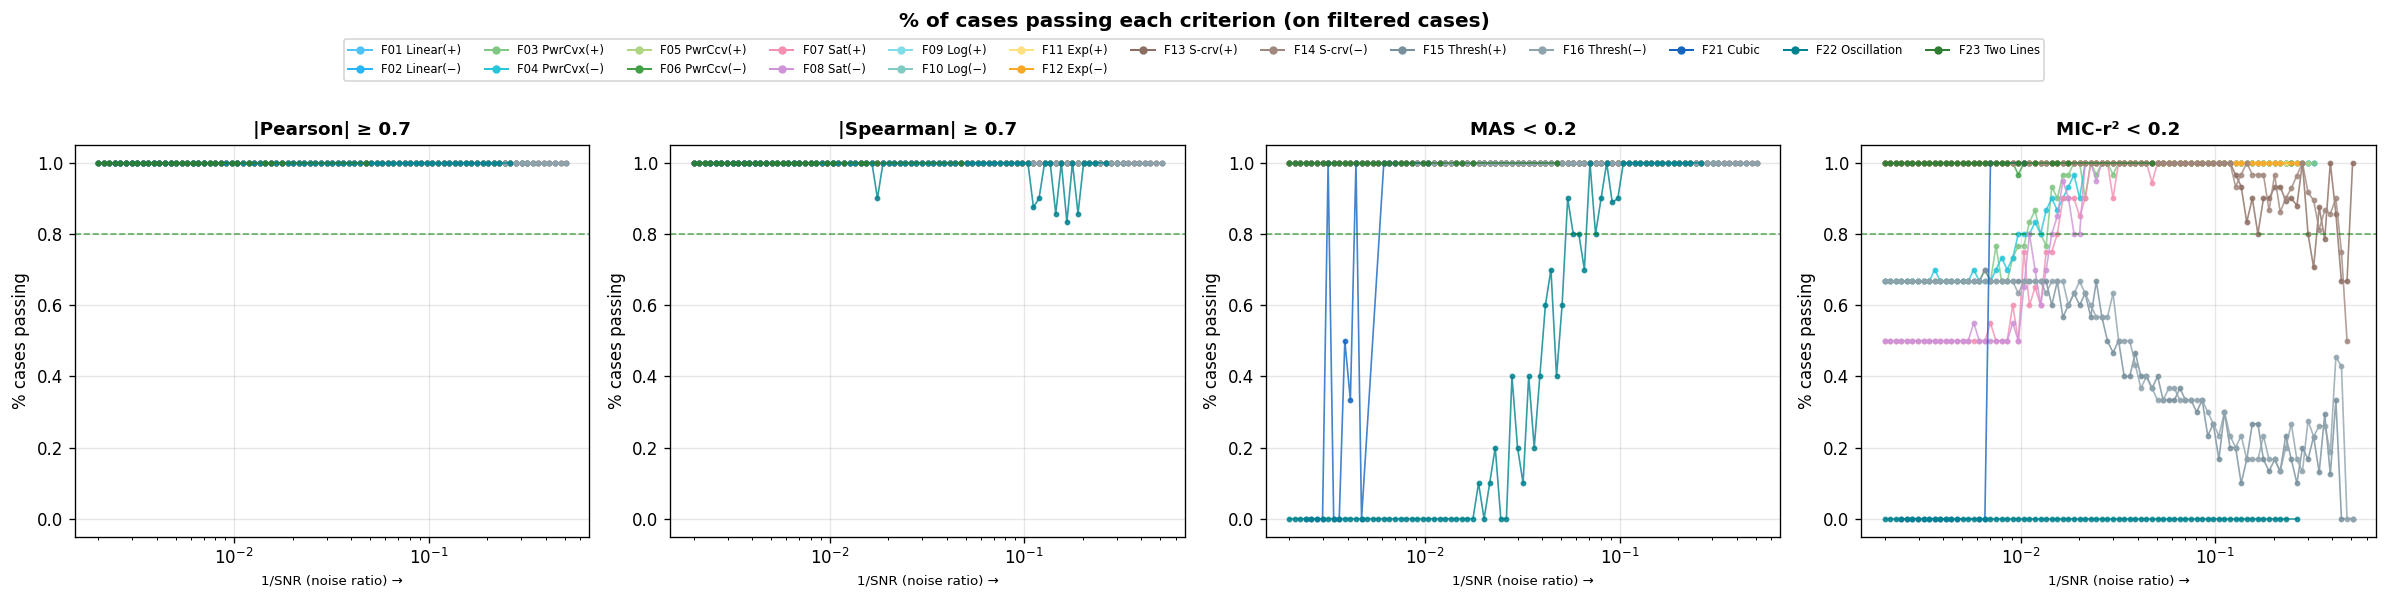

In [494]:
# ── Classify qualifying families by relationship type ──

R_THRESH = 0.7
NL_THRESH = 0.2
MR_THRESH = 0.2

# Per case: check each criterion independently
fc = filtered_cases.copy()
fc['pass_pearson'] = (fc['pearson_r'].abs() >= R_THRESH).astype(int)
fc['pass_spearman'] = (fc['spearman_rho'].abs() >= R_THRESH).astype(int)
fc['pass_mas'] = (fc['MAS'] < NL_THRESH).astype(int)
fc['pass_mic_r2'] = (fc['MIC_minus_r2'] < MR_THRESH).astype(int)
fc['pass_all'] = (fc['pass_pearson'] & fc['pass_spearman'] & fc['pass_mas'] & fc['pass_mic_r2']).astype(int)

n_pass_all_cases = fc['pass_all'].sum()

print(f'═══ Step 4: Simple/Complex Classification ═══')
print(f'Input: {len(fc):,} cases from Step 1  (out of {len(signal):,} total)')
print(f'Rule:  |r| ≥ {R_THRESH}  AND  |ρ| ≥ {R_THRESH}  AND  MAS < {NL_THRESH}  AND  MIC-r² < {MR_THRESH}')
print(f'  Cases passing ALL 4: {n_pass_all_cases:,} / {len(fc):,} ({n_pass_all_cases/len(fc):.1%} of filtered, {n_pass_all_cases/len(signal):.1%} of total)')
print()

# Build rows with classification
simple, nonlinear_mono, complex_nl = [], [], []
cat_cases = {'simple': 0, 'mono_nl': 0, 'complex': 0}
row_data = []
for fid in qual_fids:
    sub = fc[fc['family_id'] == fid]
    n = len(sub)
    p_r = sub['pass_pearson'].mean()
    p_s = sub['pass_spearman'].mean()
    p_m = sub['pass_mas'].mean()
    p_mr = sub['pass_mic_r2'].mean()
    p_all = sub['pass_all'].mean()

    if p_all >= 0.5:
        category = '✓ Simple'
        simple.append(fid)
        cat_cases['simple'] += n
    elif p_r >= 0.5 and p_s >= 0.5:
        category = '△ Mono+NL'
        nonlinear_mono.append(fid)
        cat_cases['mono_nl'] += n
    else:
        category = '✗ Complex'
        complex_nl.append(fid)
        cat_cases['complex'] += n

    row_data.append(f'{fid} {SHORT[fid]:<10} {p_r:>4.0%} {p_s:>4.0%} {p_m:>4.0%} {p_mr:>4.0%} {n:>5} {category}')

# Print in two columns
mid = (len(row_data) + 1) // 2
col_w = 53
hdr = f'{"Family":<16} {"r":>4} {"ρ":>4} {"MAS":>4} {"MR²":>4} {"N":>5} {"Cat"}'
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{"─"*col_w}  {"─"*col_w}')
for i in range(mid):
    left = row_data[i]
    right = row_data[i + mid] if i + mid < len(row_data) else ''
    print(f'{left:<{col_w}}  {right}')

print(f'\nSummary ({len(fc):,} Step-1-filtered / {len(signal):,} total):')
print(f'  ✓ Simple monotonic:      {len(simple):>2} fam, {cat_cases["simple"]:>6,} cases ({cat_cases["simple"]/len(fc):.1%})')
print(f'  △ Monotonic + nonlinear: {len(nonlinear_mono):>2} fam, {cat_cases["mono_nl"]:>6,} cases ({cat_cases["mono_nl"]/len(fc):.1%})')
print(f'  ✗ Non-mono / complex:    {len(complex_nl):>2} fam, {cat_cases["complex"]:>6,} cases ({cat_cases["complex"]/len(fc):.1%})')

# ── Plot: 1×4 — per-case pass rates vs 1/SNR ──
CLS_METRICS = [
    ('pass_pearson',  f'|Pearson| ≥ {R_THRESH}'),
    ('pass_spearman', f'|Spearman| ≥ {R_THRESH}'),
    ('pass_mas',      f'MAS < {NL_THRESH}'),
    ('pass_mic_r2',   f'MIC-r² < {MR_THRESH}'),
]

fig, axes = plt.subplots(1, 4, figsize=(5 * 4, 4.5))

for ax, (col, label) in zip(axes, CLS_METRICS):
    for fid in qual_fids:
        sub = fc[fc['family_id'] == fid]
        agg_m = sub.groupby('snr_val')[col].mean().reset_index()
        agg_m = agg_m[np.isfinite(agg_m['snr_val']) & (agg_m['snr_val'] > 0)].copy()
        agg_m['noise_ratio'] = 1.0 / agg_m['snr_val']
        agg_m = agg_m.sort_values('noise_ratio')
        ax.plot(agg_m['noise_ratio'], agg_m[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.axhline(0.8, color='green', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel('% cases passing')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=FAMILY_PALETTE[f], marker='o',
                  markersize=4, linewidth=1.2,
                  label=f'{f} {SHORT.get(f, "")}') for f in qual_fids]
fig.legend(handles=handles, loc='upper center', ncol=min(13, len(qual_fids)),
           fontsize=7, frameon=True, bbox_to_anchor=(0.5, 1.06))
fig.suptitle('% of cases passing each criterion (on filtered cases)',
             fontsize=12, fontweight='bold', y=1.10)
plt.tight_layout()
plt.show()


## Simple Path Classification: Direction → Monotonicity → Linearity → Curvature

In [495]:
# ── Simple Path: per-case classification following Scheme C flowchart ──
# Input: filtered_cases (MIC ≥ MIC_THRESH & dcor ≥ DCOR_THRESH)
# Simple condition: MIC-r² ≤ 0.2 AND |ρ| ≥ 0.7 AND |r| ≥ 0.7

R_THRESH = 0.7
MR_THRESH = 0.2
MONO_STRONG = 0.9   # |ρ| ≥ 0.9 → Strong monotonicity
LIN_STRONG = 0.9    # |r| ≥ 0.9 → Strong linearity (→ Line)
CURV_TOL = 0.15     # normalized slope < this → "≈ 0"

# ───────────────────────────────────────────────
# L2: Simple or Complex?
# ───────────────────────────────────────────────
sc = filtered_cases.copy()
sc['is_simple'] = (
    (sc['MIC_minus_r2'] < MR_THRESH) &
    (sc['spearman_rho'].abs() >= R_THRESH) &
    (sc['pearson_r'].abs() >= R_THRESH)
)

simple_cases = sc[sc['is_simple']].copy()
complex_cases = sc[~sc['is_simple']].copy()

print('═══ L2: Simple or Complex? ═══')
print(f'Rule: MIC-r² < {MR_THRESH} AND |ρ| ≥ {R_THRESH} AND |r| ≥ {R_THRESH}')
print(f'  Simple:  {len(simple_cases):>6,} / {len(sc):,}  ({len(simple_cases)/len(sc):.1%})')
print(f'  Complex: {len(complex_cases):>6,} / {len(sc):,}  ({len(complex_cases)/len(sc):.1%})')
print()
print(f'  {"Family":<16} {"Simple":>7} {"Complex":>7} {"Total":>7} {"Simple%":>8}')
print(f'  {"─"*48}')
for fid in qual_fids:
    n_s = len(simple_cases[simple_cases['family_id'] == fid])
    n_c = len(complex_cases[complex_cases['family_id'] == fid])
    n_t = n_s + n_c
    pct = n_s / n_t if n_t > 0 else 0
    print(f'  {fid} {SHORT[fid]:<10} {n_s:>7,} {n_c:>7,} {n_t:>7,} {pct:>7.0%}')

# ───────────────────────────────────────────────
# ◇ Diamond 1: Direction (sign of overall slope)
# ───────────────────────────────────────────────
simple_cases['direction'] = np.where(simple_cases['pearson_r'] > 0, 'Positive', 'Negative')

print('\n═══ ◇ Direction (sign of Pearson r) ═══')
print(f'  Denominator per family = that family\'s Simple cases')
print()
print(f'  {"Family":<16} {"Positive":>8} {"Negative":>8} {"Total":>7}')
print(f'  {"─"*42}')
simple_fids = sorted(simple_cases['family_id'].unique())
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n_pos = (sub['direction'] == 'Positive').sum()
    n_neg = (sub['direction'] == 'Negative').sum()
    print(f'  {fid} {SHORT[fid]:<10} {n_pos:>8,} {n_neg:>8,} {len(sub):>7,}')

# ───────────────────────────────────────────────
# ◇ Diamond 2: Monotonicity (|ρ| level)
# ───────────────────────────────────────────────
simple_cases['monotonicity'] = np.where(
    simple_cases['spearman_rho'].abs() >= MONO_STRONG, 'Strong', 'Med'
)

print(f'\n═══ ◇ Monotonicity (|ρ| threshold = {MONO_STRONG}) ═══')
print(f'  Denominator per family = that family\'s Simple cases')
print()
print(f'  {"Family":<16} {"Strong":>7} {"Med":>7} {"Total":>7}')
print(f'  {"─"*40}')
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n_strong = (sub['monotonicity'] == 'Strong').sum()
    n_med = (sub['monotonicity'] == 'Med').sum()
    print(f'  {fid} {SHORT[fid]:<10} {n_strong:>7,} {n_med:>7,} {len(sub):>7,}')

# ───────────────────────────────────────────────
# ◇ Diamond 3: Linearity (|r| level)
# ───────────────────────────────────────────────
simple_cases['linearity'] = np.where(
    simple_cases['pearson_r'].abs() >= LIN_STRONG, 'Strong_Line', 'Med'
)

print(f'\n═══ ◇ Linearity (|r| threshold = {LIN_STRONG}) ═══')
print(f'  Strong → terminal "Line"  |  Med → continues to Curvature')
print(f'  Denominator per family = that family\'s Simple cases')
print()
print(f'  {"Family":<16} {"Strong→Line":>12} {"Med→Curv":>9} {"Total":>7}')
print(f'  {"─"*47}')
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n_line = (sub['linearity'] == 'Strong_Line').sum()
    n_med = (sub['linearity'] == 'Med').sum()
    print(f'  {fid} {SHORT[fid]:<10} {n_line:>12,} {n_med:>9,} {len(sub):>7,}')

# ───────────────────────────────────────────────
# ◇ Diamond 4: Curvature (only for Linearity = Med)
# ───────────────────────────────────────────────
med_cases = simple_cases[simple_cases['linearity'] == 'Med'].copy()

E = med_cases['standardized_polyfit_early_slope'].values
M = med_cases['standardized_polyfit_middle_slope'].values
L = med_cases['standardized_polyfit_late_slope'].values

# Per-case normalization by max(|E|, |M|, |L|)
scale = np.maximum(np.maximum(np.abs(E), np.abs(M)), np.abs(L))
scale = np.where(scale == 0, 1, scale)  # avoid div by 0
e_n = E / scale
m_n = M / scale
l_n = L / scale

# Direction-aware: flip signs so "positive direction" convention applies
# For negative-direction cases, multiply by -1 so the pattern rules are consistent
direction_sign = np.where(med_cases['pearson_r'].values > 0, 1, -1)
e_d = e_n * direction_sign
m_d = m_n * direction_sign
l_d = l_n * direction_sign

# Curvature rules (after direction normalization, slopes should be positive for "increasing" segments)
curvature = np.full(len(med_cases), 'Other', dtype=object)

# Convex (J-shape): E ≈ 0, slopes accelerate: |E| < TOL, L > M > E
convex = (np.abs(e_d) < CURV_TOL) & (l_d > m_d) & (m_d > e_d)
curvature[convex] = 'Convex'

# Concave (Sat/L-shape): L ≈ 0, slopes decelerate: |L| < TOL, E > M > L
concave = (np.abs(l_d) < CURV_TOL) & (e_d > m_d) & (m_d > l_d)
curvature[concave] = 'Concave'

# Inflected (S-curve): E ≈ 0, L ≈ 0, M is dominant
inflected = (np.abs(e_d) < CURV_TOL) & (np.abs(l_d) < CURV_TOL) & (np.abs(m_d) >= CURV_TOL)
curvature[inflected] = 'Inflected'

med_cases['curvature'] = curvature

print(f'\n═══ ◇ Curvature (CURV_TOL = {CURV_TOL}) ═══')
print(f'  Only for Linearity = Med cases (|r| < {LIN_STRONG})')
print(f'  Denominator per family = that family\'s Med-linearity cases')
print()
print(f'  {"Family":<16} {"Convex":>7} {"Concave":>8} {"Inflect":>8} {"Other":>6} {"Total":>7}')
print(f'  {"─"*55}')
curv_fids = sorted(med_cases['family_id'].unique())
for fid in curv_fids:
    sub = med_cases[med_cases['family_id'] == fid]
    n_cx = (sub['curvature'] == 'Convex').sum()
    n_cc = (sub['curvature'] == 'Concave').sum()
    n_inf = (sub['curvature'] == 'Inflected').sum()
    n_oth = (sub['curvature'] == 'Other').sum()
    print(f'  {fid} {SHORT[fid]:<10} {n_cx:>7,} {n_cc:>8,} {n_inf:>8,} {n_oth:>6,} {len(sub):>7,}')

# ───────────────────────────────────────────────
# Summary: combined profile per family
# ───────────────────────────────────────────────
# Merge curvature back
simple_cases = simple_cases.merge(
    med_cases[['case_id', 'curvature']],
    on='case_id', how='left'
)
simple_cases['curvature'] = simple_cases['curvature'].fillna('—')
# For Strong_Line cases, curvature is not applicable
simple_cases.loc[simple_cases['linearity'] == 'Strong_Line', 'curvature'] = 'Line'

print(f'\n═══ Summary: Simple Path Profiles ═══')
print(f'  Total Simple cases: {len(simple_cases):,}')
print()
print(f'  {"Family":<16} {"Dir":>4} {"Mono":>6} {"Lin":>6} {"Curv":>9} {"N":>6}')
print(f'  {"─"*50}')

for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    # Majority labels
    dir_maj = sub['direction'].mode().iloc[0] if len(sub) > 0 else '?'
    mono_maj = sub['monotonicity'].mode().iloc[0] if len(sub) > 0 else '?'
    lin_maj = sub['linearity'].mode().iloc[0] if len(sub) > 0 else '?'
    curv_maj = sub['curvature'].mode().iloc[0] if len(sub) > 0 else '?'
    dir_short = '+' if dir_maj == 'Positive' else '−'
    print(f'  {fid} {SHORT[fid]:<10} {dir_short:>4} {mono_maj:>6} {lin_maj:>6} {curv_maj:>9} {len(sub):>6,}')


═══ L2: Simple or Complex? ═══
Rule: MIC-r² < 0.2 AND |ρ| ≥ 0.7 AND |r| ≥ 0.7
  Simple:  27,990 / 32,570  (85.9%)
  Complex:  4,580 / 32,570  (14.1%)

  Family            Simple Complex   Total  Simple%
  ────────────────────────────────────────────────
  F01 Linear(+)    2,151       0   2,151    100%
  F02 Linear(−)    2,162       0   2,162    100%
  F03 PwrCvx(+)    1,598     292   1,890     85%
  F04 PwrCvx(−)    1,608     291   1,899     85%
  F05 PwrCcv(+)    1,974       0   1,974    100%
  F06 PwrCcv(−)    1,980       1   1,981    100%
  F07 Sat(+)         813     313   1,126     72%
  F08 Sat(−)         812     308   1,120     72%
  F09 Log(+)       1,920       0   1,920    100%
  F10 Log(−)       1,914       0   1,914    100%
  F11 Exp(+)       1,974       0   1,974    100%
  F12 Exp(−)       1,969       0   1,969    100%
  F13 S-crv(+)     2,329      53   2,382     98%
  F14 S-crv(−)     2,362      34   2,396     99%
  F15 Thresh(+)    1,142   1,298   2,440     47%
  F16 Thres

Filtered cases (MIC ≥ 0.8 & dcor ≥ DCOR_THRESH): 32,570
Further filtered (|r| ≥ 0.7, |ρ| ≥ 0.7, MAS < 0.2, MIC-r² < 0.2): 27,990
Families remaining: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21', 'F23']
Bin tolerance: 3% of y-range



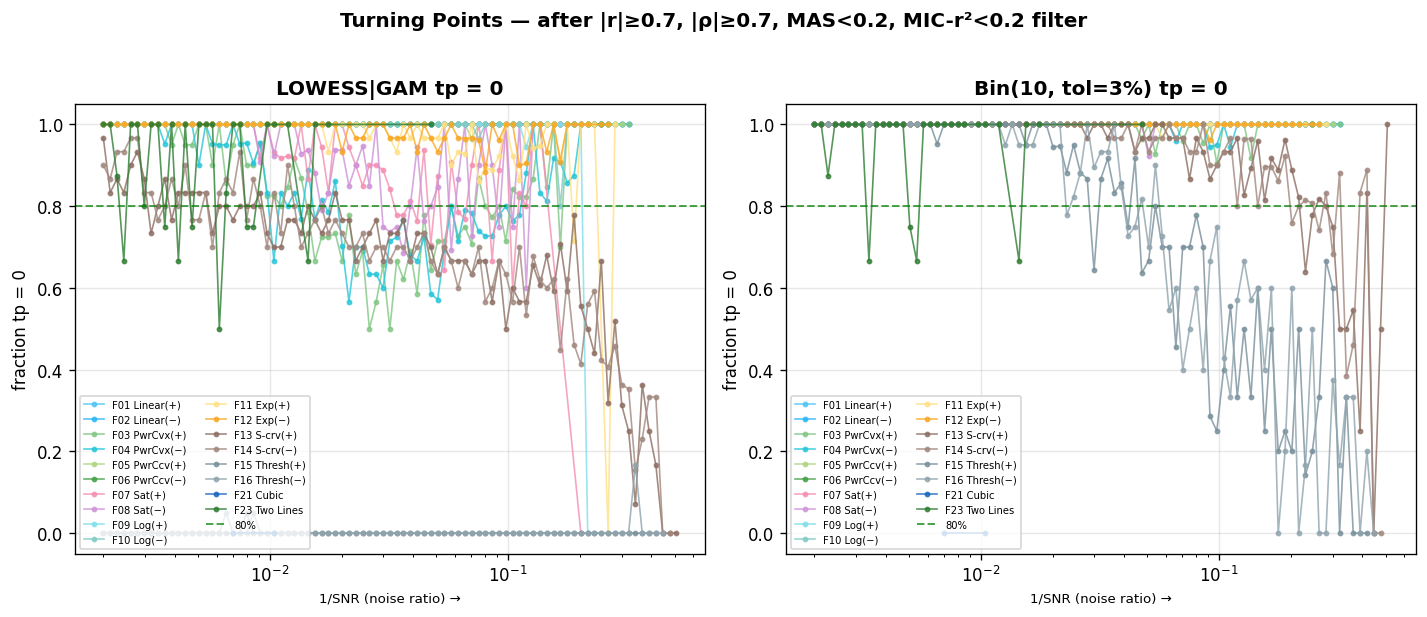

Family                        LOWESS|GAM  Bin(tol)   Cases
                                   tp=0%     tp=0%
────────────────────────────────────────────────────────────
F01 Linear(+)                      100%      100%    2151
F02 Linear(−)                      100%      100%    2162
F03 PwrCvx(+)                       81%       99%    1598
F04 PwrCvx(−)                       82%      100%    1608
F05 PwrCcv(+)                      100%      100%    1974
F06 PwrCcv(−)                      100%      100%    1980
F07 Sat(+)                          91%      100%     813
F08 Sat(−)                          91%      100%     812
F09 Log(+)                         100%      100%    1920
F10 Log(−)                         100%      100%    1914
F11 Exp(+)                          98%      100%    1974
F12 Exp(−)                          99%      100%    1969
F13 S-crv(+)                        71%       95%    2329
F14 S-crv(−)                        70%       95%    2362
F15 Thresh(+)    

In [496]:
# ── Turning Points: on cases passing Pearson/Spearman/MAS/MIC-r² ──
# From filtered cases (MIC ≥ 0.8 & dcor ≥ DCOR_THRESH),
# further require |Pearson| ≥ 0.7, |Spearman| ≥ 0.7, MAS < 0.2, MIC-r² < 0.2
# Bin-based tp with tolerance: diffs < tol*y_range treated as 0

R_THRESH = 0.7
NL_THRESH = 0.2
TP_COLS = ['lowess_first_derivative_sign_changes', 'gam_first_derivative_sign_changes']
TOL = 0.03  # 3% of y-range tolerance

fc = filtered_cases.copy()
fc['abs_pearson'] = fc['pearson_r'].abs()
fc['abs_spearman'] = fc['spearman_rho'].abs()

mono_cases = fc[
    (fc['abs_pearson'] >= R_THRESH) &
    (fc['abs_spearman'] >= R_THRESH) &
    (fc['MAS'] < NL_THRESH) &
    (fc['MIC_minus_r2'] < NL_THRESH)
].copy()

print(f'Filtered cases (MIC ≥ 0.8 & dcor ≥ DCOR_THRESH): {len(fc):,}')
print(f'Further filtered (|r| ≥ {R_THRESH}, |ρ| ≥ {R_THRESH}, MAS < {NL_THRESH}, MIC-r² < {NL_THRESH}): {len(mono_cases):,}')
print(f'Families remaining: {sorted(mono_cases["family_id"].unique())}')
print(f'Bin tolerance: {TOL:.0%} of y-range\n')

# Method 1: LOWESS OR GAM tp = 0 (no tolerance, original)
mono_cases['any_tp_zero'] = ((mono_cases[TP_COLS[0]] == 0) | (mono_cases[TP_COLS[1]] == 0)).astype(float)

# Method 2: Bin-based tp with tolerance
N_BINS = 10

def bin_turning_points_tol(x, y, n_bins=10, tol=TOL):
    order = np.argsort(x)
    y_s = y[order]
    bins = np.array_split(y_s, n_bins)
    means = np.array([b.mean() for b in bins])
    diffs = np.diff(means)
    y_range = np.nanmax(means) - np.nanmin(means)
    threshold = tol * y_range if y_range > 0 else 0
    signs = np.where(diffs > threshold, 1, np.where(diffs < -threshold, -1, 0))
    signs = signs[signs != 0]
    if len(signs) <= 1:
        return 0
    return int(np.sum(signs[1:] != signs[:-1]))

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

mono_case_ids = mono_cases['case_id'].unique()
filt_idx = cases_df[cases_df['case_id'].isin(mono_case_ids)].index
bin_tp_map = {}
for i in filt_idx:
    bin_tp_map[cases_df.loc[i, 'case_id']] = bin_turning_points_tol(
        X_all[i], Y_all[i], N_BINS, TOL)
mono_cases['bin_tp'] = mono_cases['case_id'].map(bin_tp_map)
mono_cases['bin_tp_zero'] = (mono_cases['bin_tp'] == 0).astype(float)

# ── Plot: 1×2 comparison ──
mono_fids = sorted(mono_cases['family_id'].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (col, label) in zip(axes, [
    ('any_tp_zero', 'LOWESS|GAM tp = 0'),
    ('bin_tp_zero', f'Bin({N_BINS}, tol={TOL:.0%}) tp = 0'),
]):
    for fid in mono_fids:
        sub = mono_cases[mono_cases['family_id'] == fid]
        agg_m = sub.groupby('snr_val')[col].mean().reset_index()
        agg_m = agg_m[np.isfinite(agg_m['snr_val']) & (agg_m['snr_val'] > 0)].copy()
        agg_m['noise_ratio'] = 1.0 / agg_m['snr_val']
        agg_m = agg_m.sort_values('noise_ratio')
        ax.plot(agg_m['noise_ratio'], agg_m[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT[fid]}')
    ax.axhline(0.8, color='green', linestyle='--', linewidth=1.2, alpha=0.7, label='80%')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel('fraction tp = 0')
    ax.legend(fontsize=6, ncol=2, loc='lower left', framealpha=0.8)

fig.suptitle('Turning Points — after |r|≥0.7, |ρ|≥0.7, MAS<0.2, MIC-r²<0.2 filter',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ──
print(f'{"Family":<28} {"LOWESS|GAM":>11} {"Bin(tol)":>9} {"Cases":>7}')
print(f'{"":28} {"tp=0%":>11} {"tp=0%":>9}')
print('─' * 60)
for fid in mono_fids:
    sub = mono_cases[mono_cases['family_id'] == fid]
    any_z = sub['any_tp_zero'].mean()
    bin_z = sub['bin_tp_zero'].mean()
    print(f'{fid + " " + SHORT[fid]:<28} {any_z:>10.0%} {bin_z:>9.0%} {len(sub):>7}')


Family                          Front      Mid     Back  Shape
────────────────────────────────────────────────────────────────────
F01 Linear(+)                    1.00     1.00     1.00  Uniform
F02 Linear(−)                   -1.00    -1.00    -1.00  Uniform
F03 PwrCvx(+)                    0.34     0.91     1.74  Back-heavy (exponential)
F04 PwrCvx(−)                   -0.34    -0.91    -1.75  Back-heavy (exponential)
F05 PwrCcv(+)                    1.62     0.78     0.60  Mixed
F06 PwrCcv(−)                   -1.62    -0.78    -0.60  Mixed
F07 Sat(+)                       2.10     0.67     0.23  Front-heavy (saturation)
F08 Sat(−)                      -2.10    -0.67    -0.23  Front-heavy (saturation)
F09 Log(+)                       1.81     0.72     0.46  Front-heavy (saturation)
F10 Log(−)                      -1.81    -0.73    -0.46  Front-heavy (saturation)
F11 Exp(+)                       0.42     0.83     1.75  Back-heavy (exponential)
F12 Exp(−)                      -0.42 

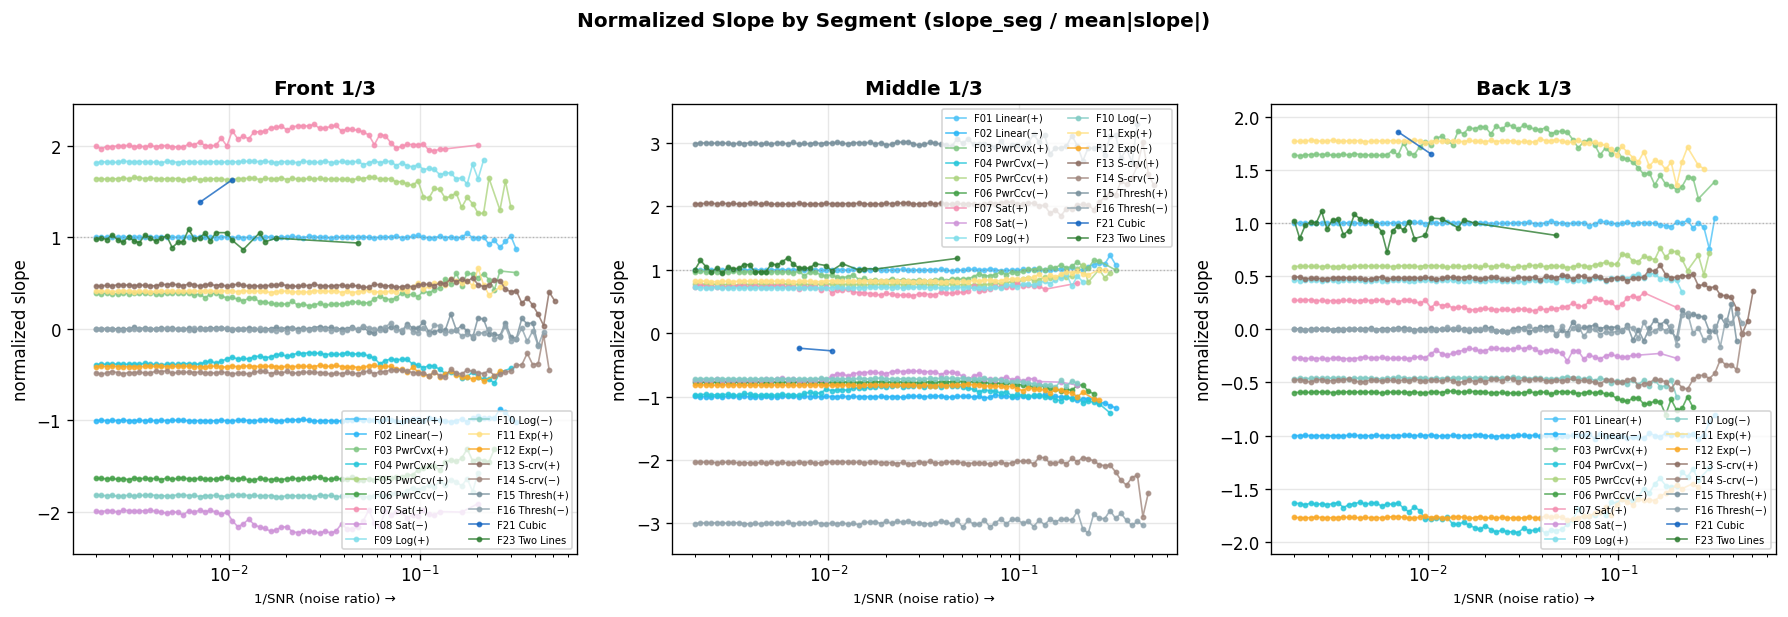

In [497]:
# ── Slope Analysis: front / middle / back thirds ──
# On the same mono_cases from cell 12,
# split each case's x-range into 3 equal segments, fit linear slope in each.

from scipy.stats import linregress

def thirds_slope(x, y):
    order = np.argsort(x)
    x_s, y_s = x[order], y[order]
    n = len(x_s)
    cut1, cut2 = n // 3, 2 * n // 3
    slopes = []
    for lo, hi in [(0, cut1), (cut1, cut2), (cut2, n)]:
        if hi - lo < 3:
            slopes.append(np.nan)
        else:
            s = linregress(x_s[lo:hi], y_s[lo:hi]).slope
            slopes.append(s)
    return slopes  # [front, mid, back]

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

mono_case_ids = mono_cases['case_id'].unique()
filt_idx = cases_df[cases_df['case_id'].isin(mono_case_ids)].index

slope_map = {}  # case_id -> (front, mid, back)
for i in filt_idx:
    cid = cases_df.loc[i, 'case_id']
    slope_map[cid] = thirds_slope(X_all[i], Y_all[i])

mono_cases['slope_front'] = mono_cases['case_id'].map(lambda c: slope_map.get(c, [np.nan]*3)[0])
mono_cases['slope_mid']   = mono_cases['case_id'].map(lambda c: slope_map.get(c, [np.nan]*3)[1])
mono_cases['slope_back']  = mono_cases['case_id'].map(lambda c: slope_map.get(c, [np.nan]*3)[2])

# Normalize: ratio of each segment slope to overall slope
mono_cases['slope_overall'] = mono_cases[['slope_front','slope_mid','slope_back']].mean(axis=1)
for seg in ['front','mid','back']:
    denom = mono_cases['slope_overall'].abs()
    mono_cases[f'slope_{seg}_norm'] = mono_cases[f'slope_{seg}'] / denom.replace(0, np.nan)

# ── Summary table: mean normalized slopes per family ──
print(f'{"Family":<28} {"Front":>8} {"Mid":>8} {"Back":>8}  Shape')
print('─' * 68)

for fid in mono_fids:
    sub = mono_cases[mono_cases['family_id'] == fid]
    sf = sub['slope_front_norm'].mean()
    sm = sub['slope_mid_norm'].mean()
    sb = sub['slope_back_norm'].mean()
    # Auto-detect shape pattern
    vals = [abs(sf), abs(sm), abs(sb)]
    mx = max(vals) if max(vals) > 0 else 1
    rel = [v/mx for v in vals]
    if all(r > 0.5 for r in rel):
        shape = 'Uniform'
    elif rel[0] > 0.5 and rel[2] < 0.3:
        shape = 'Front-heavy (saturation)'
    elif rel[2] > 0.5 and rel[0] < 0.3:
        shape = 'Back-heavy (exponential)'
    elif rel[1] > 0.5 and rel[0] < 0.3 and rel[2] < 0.3:
        shape = 'Mid-heavy (S-curve/threshold)'
    else:
        shape = 'Mixed'
    print(f'{fid + " " + SHORT[fid]:<28} {sf:>8.2f} {sm:>8.2f} {sb:>8.2f}  {shape}')

# ── Plot: 1×3 — normalized slope distributions per family ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (seg, label) in zip(axes, [
    ('slope_front_norm', 'Front 1/3'),
    ('slope_mid_norm',   'Middle 1/3'),
    ('slope_back_norm',  'Back 1/3'),
]):
    for fid in mono_fids:
        sub = mono_cases[mono_cases['family_id'] == fid]
        agg_m = sub.groupby('snr_val')[seg].mean().reset_index()
        agg_m = agg_m[np.isfinite(agg_m['snr_val']) & (agg_m['snr_val'] > 0)].copy()
        agg_m['noise_ratio'] = 1.0 / agg_m['snr_val']
        agg_m = agg_m.sort_values('noise_ratio')
        ax.plot(agg_m['noise_ratio'], agg_m[seg], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT[fid]}')
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel('normalized slope')
    ax.legend(fontsize=6, ncol=2, loc='best', framealpha=0.8)

fig.suptitle('Normalized Slope by Segment (slope_seg / mean|slope|)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [498]:
# ── Combined Classification: all criteria ──

R_THRESH = 0.7
NL_THRESH = 0.2
TP_FRAC = 0.8   # ≥ 80% of cases must have tp = 0

# tp lookup from mono_cases (cell 12, denominator = cases passing r/ρ/MAS/MIC-r²)
tp_lookup = mono_cases.groupby('family_id')['any_tp_zero'].mean().to_dict()

rows = []
for fid in qual_fids:
    sub = filtered_cases[filtered_cases['family_id'] == fid]
    n = len(sub)
    p_r  = (sub['pearson_r'].abs() >= R_THRESH).mean()
    p_s  = (sub['spearman_rho'].abs() >= R_THRESH).mean()
    p_m  = (sub['MAS'] < NL_THRESH).mean()
    p_mr = (sub['MIC_minus_r2'] < NL_THRESH).mean()
    p_all = ((sub['pearson_r'].abs() >= R_THRESH) &
             (sub['spearman_rho'].abs() >= R_THRESH) &
             (sub['MAS'] < NL_THRESH) &
             (sub['MIC_minus_r2'] < NL_THRESH)).mean()
    any_tp = tp_lookup.get(fid, float('nan'))

    # Classification
    if p_all >= 0.5 and any_tp >= TP_FRAC:
        category = 'A: Simple monotonic'
    elif p_r >= 0.5 and p_s >= 0.5 and any_tp >= TP_FRAC:
        category = 'B: Monotonic + nonlinear'
    elif p_r >= 0.5 and p_s >= 0.5:
        category = 'C: Monotonic (tp unstable)'
    else:
        category = 'D: Non-monotonic / complex'

    rows.append({
        'fid': fid, 'name': SHORT[fid],
        'p_r': p_r, 'p_s': p_s, 'p_m': p_m, 'p_mr': p_mr, 'p_all': p_all,
        'tp': any_tp, 'n': n, 'category': category,
    })

# Print
print(f'═══ Combined Classification ═══')
print(f'Input: {len(filtered_cases):,} cases from Step 1  (out of {len(signal):,} total)')
print(f'Criteria:  |r|,|ρ| ≥ {R_THRESH}  |  MAS,MIC-r² < {NL_THRESH}  |  tp=0 ≥ {int(TP_FRAC*100)}%')
print()
print(f'{"Family":<28} {"r≥0.7":>7} {"ρ≥0.7":>7} {"MAS<0.2":>8} {"MR²<0.2":>8} {"ALL":>7} {"tp=0%":>7} {"Cases":>7}  Category')
print('─' * 105)

for r in rows:
    tp_str = f'{r["tp"]:>6.0%}' if not np.isnan(r['tp']) else f'{"N/A":>6}'
    print(f'{r["fid"] + " " + r["name"]:<28} '
          f'{r["p_r"]:>6.0%} {r["p_s"]:>7.0%} {r["p_m"]:>8.0%} {r["p_mr"]:>8.0%} '
          f'{r["p_all"]:>7.0%} {tp_str} {r["n"]:>7}  {r["category"]}')

print(f'\nSummary (out of {len(filtered_cases):,} Step-1-filtered / {len(signal):,} total):')
for cat in ['A: Simple monotonic', 'B: Monotonic + nonlinear',
            'C: Monotonic (tp unstable)', 'D: Non-monotonic / complex']:
    fams = [r for r in rows if r['category'] == cat]
    if fams:
        n_cases = sum(r['n'] for r in fams)
        names = ', '.join(f'{r["fid"]}' for r in fams)
        print(f'  {cat}: {len(fams)} families, {n_cases:,} cases ({n_cases/len(filtered_cases):.1%} of filtered, {n_cases/len(signal):.1%} of total)  — {names}')
    else:
        print(f'  {cat}: 0 families')


═══ Combined Classification ═══
Input: 32,570 cases from Step 1  (out of 156,780 total)
Criteria:  |r|,|ρ| ≥ 0.7  |  MAS,MIC-r² < 0.2  |  tp=0 ≥ 80%

Family                         r≥0.7   ρ≥0.7  MAS<0.2  MR²<0.2     ALL   tp=0%   Cases  Category
─────────────────────────────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)                  100%    100%     100%     100%    100%   100%    2151  A: Simple monotonic
F02 Linear(−)                  100%    100%     100%     100%    100%   100%    2162  A: Simple monotonic
F03 PwrCvx(+)                  100%    100%     100%      85%     85%    81%    1890  A: Simple monotonic
F04 PwrCvx(−)                  100%    100%     100%      85%     85%    82%    1899  A: Simple monotonic
F05 PwrCcv(+)                  100%    100%     100%     100%    100%   100%    1974  A: Simple monotonic
F06 PwrCcv(−)                  100%    100%     100%     100%    100%   100%    1981  A: Simple monotonic
F07 Sat(+) 

## Step 5 — MCN & Normalized MCN (relationship complexity)

MCN (Maximum Cell Number) = log₂ of the grid resolution needed to achieve MIC.
- **Low MCN** (≈ 2): simple functional relationship (a coarse 2×2 grid captures it)
- **High MCN** (→ log₂B): complex/multi-regime relationship (needs fine grid)

**Normalized MCN** = MCN / log₂(B), where B = n^α = 500^0.6 ≈ 41.6, so log₂(B) ≈ 5.38.
Range [0, 1]: 0 = simplest, 1 = most complex.

MINE params: alpha=0.6, n=500, B=n^α=41.63, log₂(B)=5.3795
Normalized MCN = MCN / log₂(B),  range ≈ [0.37, 1.0]

Family                          MCN∞   norm∞  MCN_all  norm_all   Cases  Complexity (at ∞)
───────────────────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)                  2.000   0.372    4.932     0.917    2151  Low (simple functional)
F02 Linear(−)                  2.000   0.372    4.928     0.916    2162  Low (simple functional)
F03 PwrCvx(+)                  2.000   0.372    4.986     0.927    1890  Low (simple functional)
F04 PwrCvx(−)                  2.000   0.372    4.984     0.926    1899  Low (simple functional)
F05 PwrCcv(+)                  2.000   0.372    5.018     0.933    1974  Low (simple functional)
F06 PwrCcv(−)                  2.000   0.372    5.025     0.934    1981  Low (simple functional)
F07 Sat(+)                     2.000   0.372    5.090     0.946    1126  Low (simple functional)
F08 Sat(−)           

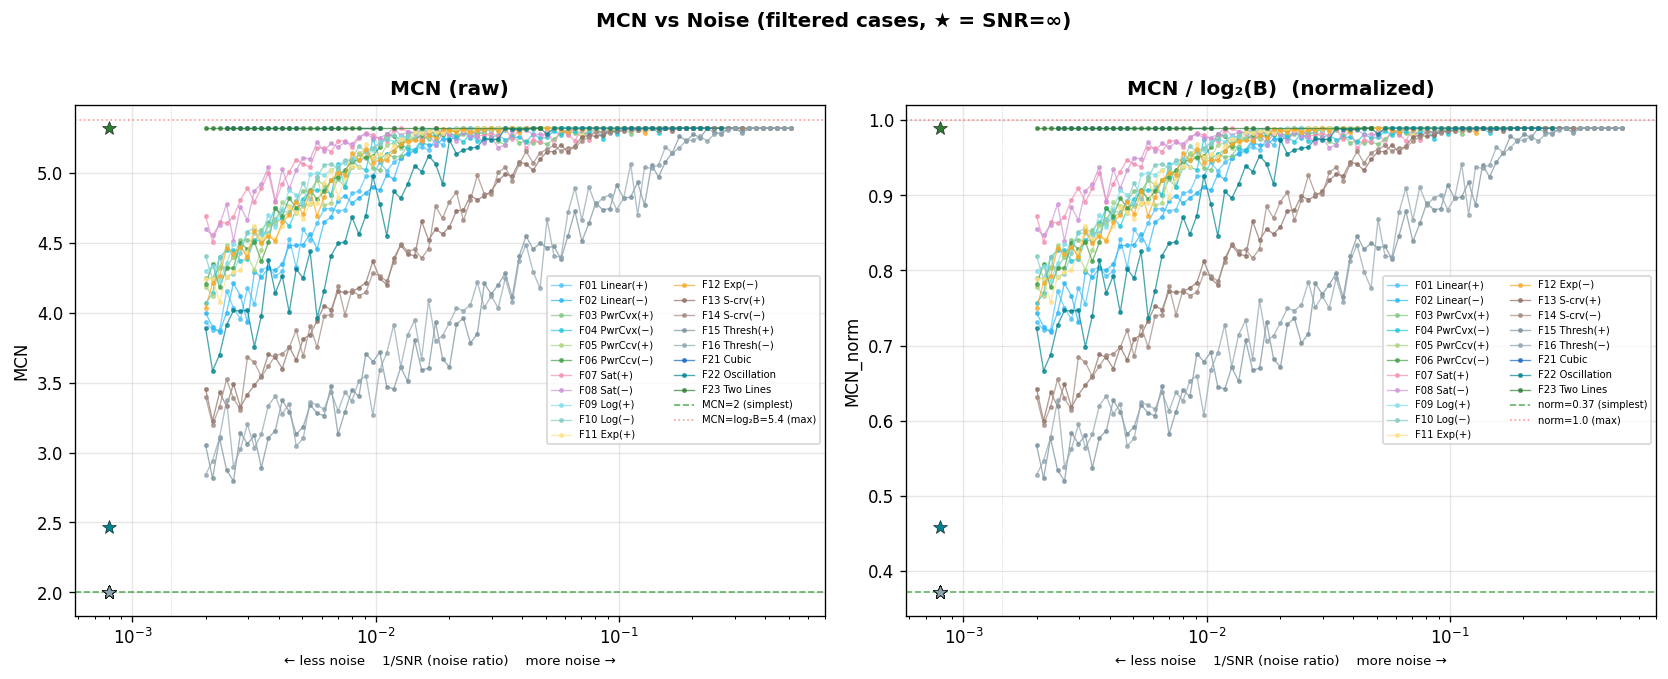

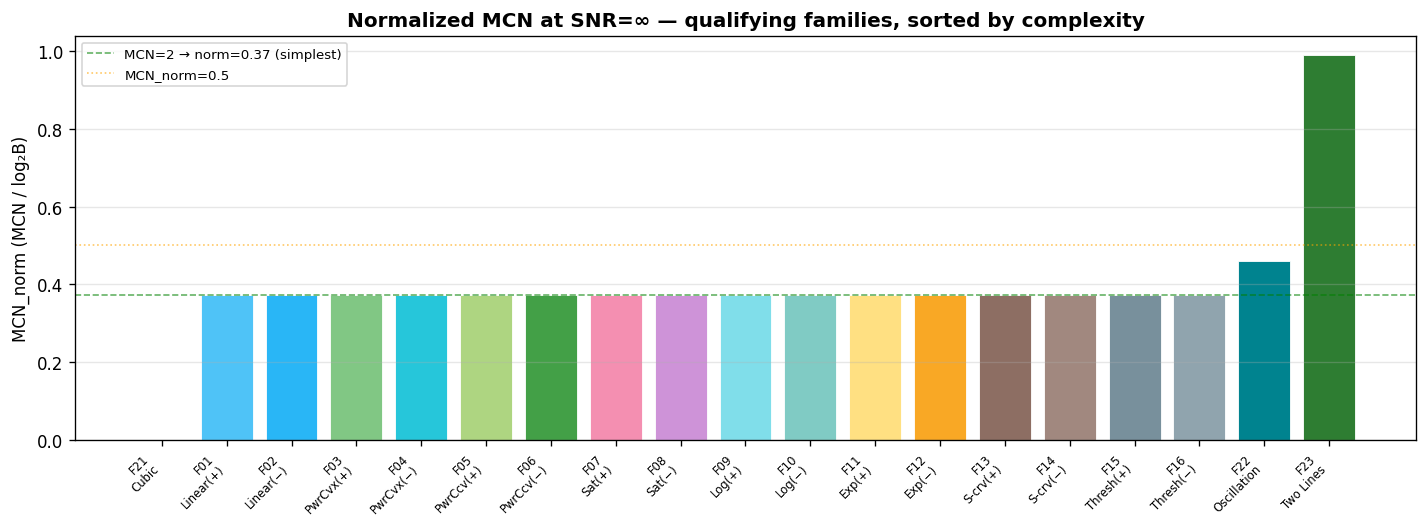

In [499]:
# ── MCN & Normalized MCN ──
# MINE was run with alpha=0.6, c=15, n=500
# B = n^alpha = 500^0.6 ≈ 41.63;  log2(B) ≈ 5.38
ALPHA = 0.6
N_SAMPLES = 500
B = N_SAMPLES ** ALPHA
LOG2_B = np.log2(B)

# Compute normalized MCN on filtered_cases
filtered_cases['MCN_norm'] = filtered_cases['MCN'] / LOG2_B

# ── Part A: Summary table — mean MCN per family (SNR=inf vs all filtered) ──
print(f'MINE params: alpha={ALPHA}, n={N_SAMPLES}, B=n^α={B:.2f}, log₂(B)={LOG2_B:.4f}')
print(f'Normalized MCN = MCN / log₂(B),  range ≈ [0.37, 1.0]\n')

fc_inf = filtered_cases[np.isinf(filtered_cases['snr_val'])]
mcn_inf_lookup = fc_inf.groupby('family_id')['MCN'].mean().to_dict()
mcn_norm_inf_lookup = fc_inf.groupby('family_id')['MCN_norm'].mean().to_dict()

print(f'{"Family":<28} {"MCN∞":>7} {"norm∞":>7} {"MCN_all":>8} {"norm_all":>9} {"Cases":>7}  Complexity (at ∞)')
print('─' * 95)

for fid in qual_fids:
    sub = filtered_cases[filtered_cases['family_id'] == fid]
    mcn_inf = mcn_inf_lookup.get(fid, np.nan)
    mcn_n_inf = mcn_norm_inf_lookup.get(fid, np.nan)
    mcn_all = sub['MCN'].mean()
    mcn_n_all = sub['MCN_norm'].mean()
    n = len(sub)

    if mcn_n_inf < 0.45:
        cplx = 'Low (simple functional)'
    elif mcn_n_inf < 0.55:
        cplx = 'Medium (non-monotonic)'
    elif mcn_n_inf < 0.75:
        cplx = 'High'
    else:
        cplx = 'Very high (multi-regime)'

    print(f'{fid + " " + SHORT[fid]:<28} {mcn_inf:>7.3f} {mcn_n_inf:>7.3f} {mcn_all:>8.3f} {mcn_n_all:>9.3f} {n:>7}  {cplx}')

print(f'\n  MCN∞ = MCN at SNR=∞ (no noise, true complexity)')
print(f'  MCN_all = mean MCN across all filtered cases (noise inflates MCN)')

# ── Part B: Line plot — MCN_norm vs 1/SNR on filtered_cases ──
# SNR=∞ → plotted as ★ at x left of the smallest finite 1/SNR

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (col, label) in zip(axes, [
    ('MCN', 'MCN (raw)'),
    ('MCN_norm', 'MCN / log₂(B)  (normalized)'),
]):
    finite_snrs = filtered_cases['snr_val'][
        np.isfinite(filtered_cases['snr_val']) & (filtered_cases['snr_val'] > 0)]
    max_snr = finite_snrs.max()
    star_x = 1.0 / max_snr * 0.4

    for fid in qual_fids:
        sub = filtered_cases[filtered_cases['family_id'] == fid]
        agg_m = sub.groupby('snr_val')[col].mean().reset_index()

        # Finite SNR → line
        finite_agg = agg_m[np.isfinite(agg_m['snr_val']) & (agg_m['snr_val'] > 0)].copy()
        if len(finite_agg) > 0:
            finite_agg['noise_ratio'] = 1.0 / finite_agg['snr_val']
            finite_agg = finite_agg.sort_values('noise_ratio')
            ax.plot(finite_agg['noise_ratio'], finite_agg[col], '-o',
                    color=FAMILY_PALETTE[fid],
                    markersize=2, linewidth=0.8, alpha=0.7,
                    label=f'{fid} {SHORT.get(fid, "")}')

        # SNR=∞ → ★
        inf_agg = agg_m[np.isinf(agg_m['snr_val'])]
        if len(inf_agg) > 0:
            ax.plot(star_x, inf_agg[col].values[0], '*',
                    color=FAMILY_PALETTE[fid],
                    markersize=9, markeredgecolor='black', markeredgewidth=0.3,
                    zorder=5)

    if col == 'MCN':
        ax.axhline(2.0, color='green', linestyle='--', linewidth=1.0, alpha=0.6,
                   label='MCN=2 (simplest)')
        ax.axhline(LOG2_B, color='red', linestyle=':', linewidth=1.0, alpha=0.4,
                   label=f'MCN=log₂B={LOG2_B:.1f} (max)')
    else:
        ax.axhline(2.0/LOG2_B, color='green', linestyle='--', linewidth=1.0, alpha=0.6,
                   label=f'norm={2/LOG2_B:.2f} (simplest)')
        ax.axhline(1.0, color='red', linestyle=':', linewidth=1.0, alpha=0.4,
                   label='norm=1.0 (max)')

    ax.axvline(star_x * 1.8, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.annotate('★ = SNR=∞', xy=(star_x, 1.5 if col == 'MCN' else 0.28),
                fontsize=7, ha='center', color='gray')

    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('← less noise    1/SNR (noise ratio)    more noise →', fontsize=8)
    ax.set_ylabel(col)
    ax.legend(fontsize=6, ncol=2, loc='best', framealpha=0.8)

fig.suptitle('MCN vs Noise (filtered cases, ★ = SNR=∞)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Part C: Bar chart — MCN_norm at SNR=∞ for qualifying families ──
fig, ax = plt.subplots(figsize=(12, 4.5))

fam_order = sorted(qual_fids, key=lambda f: mcn_inf_lookup.get(f, 0))
x_pos = range(len(fam_order))
bars = [mcn_norm_inf_lookup.get(f, 0) for f in fam_order]
colors = [FAMILY_PALETTE.get(f, '#999') for f in fam_order]

ax.bar(x_pos, bars, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{f}\n{SHORT.get(f,"")}' for f in fam_order],
                   fontsize=7, rotation=45, ha='right')
ax.set_ylabel('MCN_norm (MCN / log₂B)')
ax.set_title('Normalized MCN at SNR=∞ — qualifying families, sorted by complexity',
             fontweight='bold', fontsize=12)
ax.axhline(2.0 / LOG2_B, color='green', linestyle='--', linewidth=1.0, alpha=0.6,
           label=f'MCN=2 → norm={2/LOG2_B:.2f} (simplest)')
ax.axhline(0.5, color='orange', linestyle=':', linewidth=1.0, alpha=0.6,
           label='MCN_norm=0.5')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [500]:
# ── Export: full classification path for all 26 families ──
# Builds one row per family showing each diamond's numerator/denominator/result

# Also export filtered_cases as before
filtered_cases.to_csv(S2_DIR / 'filtered_MIC_dcor.csv', index=False)
print(f'Saved {len(filtered_cases):,} qualifying cases to output/S2/filtered_MIC_dcor.csv')

# ── Build classification summary ──
total_per_fid = signal.groupby('family_id').size()

export_rows = []
for fid in all_fids:
    row = {'family_id': fid, 'short_name': SHORT.get(fid, '')}

    n_total = int(total_per_fid.get(fid, 0))

    # ── L1: Global relationship ──
    l1_pass = len(filtered_cases[filtered_cases['family_id'] == fid])
    row['L1_pass'] = l1_pass
    row['L1_total'] = n_total
    row['L1_pct'] = l1_pass / n_total if n_total > 0 else 0
    row['L1_result'] = 'Pass' if l1_pass > 0 else 'Fail'

    if l1_pass == 0:
        for col in ['L2_simple','L2_complex','L2_total','L2_result',
                     'dir_pos','dir_neg','dir_total','dir_result',
                     'mono_strong','mono_med','mono_total','mono_result',
                     'lin_strong','lin_med','lin_total','lin_result',
                     'curv_convex','curv_concave','curv_inflected','curv_other','curv_total','curv_result',
                     'profile']:
            row[col] = '—'
        export_rows.append(row)
        continue

    # ── L2: Simple or Complex ──
    fid_filtered = sc[sc['family_id'] == fid]
    n_simple = int(fid_filtered['is_simple'].sum())
    n_complex = int((~fid_filtered['is_simple']).sum())
    row['L2_simple'] = n_simple
    row['L2_complex'] = n_complex
    row['L2_total'] = l1_pass
    if n_simple == 0:
        row['L2_result'] = 'Complex'
    elif n_complex == 0:
        row['L2_result'] = 'Simple'
    else:
        row['L2_result'] = 'Simple' if n_simple >= n_complex else 'Complex'

    if n_simple == 0:
        for col in ['dir_pos','dir_neg','dir_total','dir_result',
                     'mono_strong','mono_med','mono_total','mono_result',
                     'lin_strong','lin_med','lin_total','lin_result',
                     'curv_convex','curv_concave','curv_inflected','curv_other','curv_total','curv_result',
                     'profile']:
            row[col] = '—'
        export_rows.append(row)
        continue

    # ── ◇ Direction ──
    fid_simple = simple_cases[simple_cases['family_id'] == fid]
    n_pos = int((fid_simple['direction'] == 'Positive').sum())
    n_neg = int((fid_simple['direction'] == 'Negative').sum())
    row['dir_pos'] = n_pos
    row['dir_neg'] = n_neg
    row['dir_total'] = n_simple
    row['dir_result'] = fid_simple['direction'].mode().iloc[0]

    # ── ◇ Monotonicity ──
    n_mono_s = int((fid_simple['monotonicity'] == 'Strong').sum())
    n_mono_m = int((fid_simple['monotonicity'] == 'Med').sum())
    row['mono_strong'] = n_mono_s
    row['mono_med'] = n_mono_m
    row['mono_total'] = n_simple
    row['mono_result'] = fid_simple['monotonicity'].mode().iloc[0]

    # ── ◇ Linearity ──
    n_lin_s = int((fid_simple['linearity'] == 'Strong_Line').sum())
    n_lin_m = int((fid_simple['linearity'] == 'Med').sum())
    row['lin_strong'] = n_lin_s
    row['lin_med'] = n_lin_m
    row['lin_total'] = n_simple
    row['lin_result'] = 'Line' if fid_simple['linearity'].mode().iloc[0] == 'Strong_Line' else 'Med'

    # ── ◇ Curvature (only for Med linearity) ──
    if n_lin_m == 0:
        row['curv_convex'] = '—'
        row['curv_concave'] = '—'
        row['curv_inflected'] = '—'
        row['curv_other'] = '—'
        row['curv_total'] = '—'
        row['curv_result'] = '—'
    else:
        fid_med = med_cases[med_cases['family_id'] == fid]
        row['curv_convex'] = int((fid_med['curvature'] == 'Convex').sum())
        row['curv_concave'] = int((fid_med['curvature'] == 'Concave').sum())
        row['curv_inflected'] = int((fid_med['curvature'] == 'Inflected').sum())
        row['curv_other'] = int((fid_med['curvature'] == 'Other').sum())
        row['curv_total'] = n_lin_m
        row['curv_result'] = fid_med['curvature'].mode().iloc[0]

    # ── Profile string ──
    dir_s = '+' if row['dir_result'] == 'Positive' else '−'
    if row['lin_result'] == 'Line':
        row['profile'] = f"{dir_s}, {row['mono_result']}, Line"
    else:
        curv_s = row['curv_result'] if row['curv_result'] != '—' else '?'
        row['profile'] = f"{dir_s}, {row['mono_result']}, Med, {curv_s}"

    export_rows.append(row)

# Build DataFrame and export
cls_df = pd.DataFrame(export_rows)
col_order = ['family_id', 'short_name',
             'L1_pass', 'L1_total', 'L1_pct', 'L1_result',
             'L2_simple', 'L2_complex', 'L2_total', 'L2_result',
             'dir_pos', 'dir_neg', 'dir_total', 'dir_result',
             'mono_strong', 'mono_med', 'mono_total', 'mono_result',
             'lin_strong', 'lin_med', 'lin_total', 'lin_result',
             'curv_convex', 'curv_concave', 'curv_inflected', 'curv_other', 'curv_total', 'curv_result',
             'profile']
cls_df = cls_df[col_order]

cls_path = S2_DIR / 'simple_path_classification.csv'
cls_df.to_csv(cls_path, index=False)
print(f'\nSaved classification to {cls_path}')

# ── Print full table ──
print(f'\n═══ Full Classification Path (all 26 families) ═══\n')

# Two-section display: L1/L2 then Simple path details
print('── Section A: L1 & L2 ──')
print(f'  {"Family":<16} {"L1_pass":>7} {"L1_tot":>7} {"L1%":>5} {"L1":>5}  {"Simple":>7} {"Complex":>7} {"L2":>8}')
print(f'  {"─"*72}')
for _, r in cls_df.iterrows():
    fid = r['family_id']
    l1p = r['L1_pass'] if r['L1_pass'] != '—' else 0
    l1t = r['L1_total'] if r['L1_total'] != '—' else 0
    l1pct = f"{r['L1_pct']:.0%}" if r['L1_pct'] != '—' else '—'
    l2s = r['L2_simple'] if r['L2_simple'] != '—' else '—'
    l2c = r['L2_complex'] if r['L2_complex'] != '—' else '—'
    print(f'  {fid} {SHORT[fid]:<10} {l1p:>7} {l1t:>7} {l1pct:>5} {r["L1_result"]:>5}  {str(l2s):>7} {str(l2c):>7} {r["L2_result"]:>8}')

print()
print('── Section B: Simple Path (Direction → Mono → Lin → Curv) ──')
print(f'  {"Family":<16} {"Pos":>5} {"Neg":>5} {"Dir":>4}  {"Str":>5} {"Med":>5} {"Mono":>5}  {"Line":>5} {"Med":>5} {"Lin":>5}  {"Cvx":>4} {"Ccv":>4} {"Inf":>4} {"Oth":>4} {"Curv":>9}  {"Profile"}')
print(f'  {"─"*110}')
for _, r in cls_df.iterrows():
    fid = r['family_id']
    if r['L2_result'] == '—' or r['dir_pos'] == '—':
        print(f'  {fid} {SHORT[fid]:<10} {"—":>5} {"—":>5} {"—":>4}  {"—":>5} {"—":>5} {"—":>5}  {"—":>5} {"—":>5} {"—":>5}  {"—":>4} {"—":>4} {"—":>4} {"—":>4} {"—":>9}  —')
        continue
    # Direction
    dp, dn = r['dir_pos'], r['dir_neg']
    dr = '+' if r['dir_result'] == 'Positive' else '−'
    # Monotonicity
    ms, mm = r['mono_strong'], r['mono_med']
    mr = r['mono_result'][:3]
    # Linearity
    ls, lm = r['lin_strong'], r['lin_med']
    lr = r['lin_result'][:4]
    # Curvature
    if r['curv_total'] == '—':
        cx = cc = inf = oth = '—'
        cr = '—'
    else:
        cx, cc, inf, oth = r['curv_convex'], r['curv_concave'], r['curv_inflected'], r['curv_other']
        cr = r['curv_result']

    print(f'  {fid} {SHORT[fid]:<10} {dp:>5} {dn:>5} {dr:>4}  {ms:>5} {mm:>5} {mr:>5}  {ls:>5} {lm:>5} {lr:>5}  {str(cx):>4} {str(cc):>4} {str(inf):>4} {str(oth):>4} {cr:>9}  {r["profile"]}')


Saved 32,570 qualifying cases to output/S2/filtered_MIC_dcor.csv

Saved classification to output/S2/simple_path_classification.csv

═══ Full Classification Path (all 26 families) ═══

── Section A: L1 & L2 ──
  Family           L1_pass  L1_tot   L1%    L1   Simple Complex       L2
  ────────────────────────────────────────────────────────────────────────
  F01 Linear(+)     2151    6030   36%  Pass     2151       0   Simple
  F02 Linear(−)     2162    6030   36%  Pass     2162       0   Simple
  F03 PwrCvx(+)     1890    6030   31%  Pass     1598     292   Simple
  F04 PwrCvx(−)     1899    6030   31%  Pass     1608     291   Simple
  F05 PwrCcv(+)     1974    6030   33%  Pass     1974       0   Simple
  F06 PwrCcv(−)     1981    6030   33%  Pass     1980       1   Simple
  F07 Sat(+)        1126    6030   19%  Pass      813     313   Simple
  F08 Sat(−)        1120    6030   19%  Pass      812     308   Simple
  F09 Log(+)        1920    6030   32%  Pass     1920       0   Simple
  F1